custom modules

In [23]:
%%writefile visualization.py

"""
Visualization utilities cho VQA CLIP v2
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
import requests
from io import BytesIO
from collections import Counter
import cv2


def visualize_attention_v2(image, attention_weights, question, prediction, confidence, 
                          save_path=None, title=None):
    """
    Trực quan hóa attention weights trên hình ảnh
    
    Args:
        image: PIL Image hoặc numpy array
        attention_weights: Tensor attention weights [num_patches]
        question: Câu hỏi
        prediction: Câu trả lời dự đoán
        confidence: Độ tin cậy
        save_path: Đường dẫn lưu
        title: Tiêu đề tùy chỉnh
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Convert image nếu cần
    if isinstance(image, torch.Tensor):
        # Unnormalize nếu đã được normalize
        image = image.cpu().numpy().transpose(1, 2, 0)
        # Clip giá trị
        image = np.clip(image, 0, 1)
    elif not isinstance(image, np.ndarray):
        image = np.array(image)
    
    # Đảm bảo image có giá trị từ 0-1
    if image.max() > 1:
        image = image / 255.0
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    # Attention map
    attention_np = attention_weights.cpu().numpy() if isinstance(attention_weights, torch.Tensor) else attention_weights

    # Always force attention to 1D vector of length 49 (for ViT-B/32)
    target_size = 49
    if np.isscalar(attention_np) or np.ndim(attention_np) == 0:
        attention_np = np.ones(target_size) * float(attention_np)
    elif np.ndim(attention_np) == 1:
        if len(attention_np) == 1:
            attention_np = np.ones(target_size) * float(attention_np[0])
        elif len(attention_np) != target_size:
            # Pad or truncate
            if len(attention_np) > target_size:
                attention_np = attention_np[:target_size]
            else:
                attention_np = np.pad(attention_np, (0, target_size - len(attention_np)), constant_values=0)
    else:
        # Flatten any higher-dim to 1D and pad/truncate
        attention_np = np.array(attention_np).flatten()
        if len(attention_np) > target_size:
            attention_np = attention_np[:target_size]
        else:
            attention_np = np.pad(attention_np, (0, target_size - len(attention_np)), constant_values=0)

    grid_size = 7
    attention_map = attention_np.reshape(grid_size, grid_size)
    
    # Resize attention map để match image size
    attention_resized = cv2.resize(attention_map, (image.shape[1], image.shape[0]))
    
    axes[1].imshow(attention_resized, cmap='hot', alpha=0.8)
    axes[1].set_title('Attention Heatmap')
    axes[1].axis('off')
    
    # Overlay
    axes[2].imshow(image)
    axes[2].imshow(attention_resized, cmap='hot', alpha=0.4)
    axes[2].set_title('Attention Overlay')
    axes[2].axis('off')
    
    # Add text info
    info_text = f"Q: {question}\nA: {prediction}\nConfidence: {confidence:.3f}"
    plt.figtext(0.02, 0.02, info_text, fontsize=10, 
                bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8))
    
    if title:
        plt.suptitle(title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()


def demo_model_predictions(model, processor, image_urls, questions, 
                          idx_to_answer, device, save_dir=None):
    """
    Demo model với các hình ảnh từ URLs
    
    Args:
        model: Trained model
        processor: CLIP processor
        image_urls: List URLs hình ảnh
        questions: List câu hỏi tương ứng
        idx_to_answer: Mapping từ index sang answer
        device: Device
        save_dir: Thư mục lưu kết quả
    """
    model.eval()
    
    print("🎯 Running Model Demo")
    print("=" * 50)
    
    for i, (url, question) in enumerate(zip(image_urls, questions)):
        try:
            print(f"\n📸 Example {i+1}")
            print(f"Question: {question}")
            
            # Load image from URL
            try:
                response = requests.get(url, timeout=10)
                image = Image.open(BytesIO(response.content)).convert('RGB')
            except Exception as e:
                print(f"❌ Error loading image: {e}")
                continue
            
            # Process image
            image_inputs = processor(images=image, return_tensors="pt")
            pixel_values = image_inputs['pixel_values'].to(device)
            
            # Tokenize question
            tokenized_question = processor.tokenizer(
                [question],
                padding=True,
                truncation=True,
                max_length=77,
                return_tensors="pt"
            ).to(device)
            
            # Predict
            with torch.no_grad():
                logits, attention_weights = model(pixel_values, tokenized_question)
                probs = torch.softmax(logits, dim=-1)
                pred_idx = torch.argmax(logits, dim=-1).item()
                confidence = probs[0, pred_idx].item()
                
                pred_answer = idx_to_answer.get(pred_idx, "unknown")
            
            print(f"Predicted Answer: {pred_answer}")
            print(f"Confidence: {confidence:.3f}")
            
            # Visualize
            save_path = None
            if save_dir:
                save_path = f"{save_dir}/demo_example_{i+1}.png"
            
            visualize_attention_v2(
                image=image,
                attention_weights=attention_weights[0],
                question=question,
                prediction=pred_answer,
                confidence=confidence,
                save_path=save_path,
                title=f"Demo Example {i+1}"
            )
            
        except Exception as e:
            print(f"❌ Error processing example {i+1}: {e}")
            continue
    
    print("\n✅ Demo completed!")


def analyze_predictions_v2(model, dataloader, idx_to_answer, device, 
                          num_samples=500, save_dir=None, processor=None):
    """
    Phân tích chi tiết predictions của model
    
    Args:
        model: Trained model
        dataloader: DataLoader
        idx_to_answer: Mapping từ index sang answer
        device: Device
        num_samples: Number of samples to analyze
        save_dir: Directory to save results
        processor: CLIP processor for tokenizing questions
        num_samples: Số samples để phân tích
        save_dir: Thư mục lưu kết quả
        
    Returns:
        analysis_results: Dict chứa kết quả phân tích
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_confidences = []
    all_questions = []
    sample_count = 0
    
    print(f"🔍 Analyzing {num_samples} predictions...")
    
    with torch.no_grad():
        for batch in dataloader:
            if sample_count >= num_samples:
                break
                
            pixel_values = batch['pixel_values'].to(device)
            # Handle both 'question' and 'questions' keys
            if 'question' in batch:
                raw_questions = batch['question']
            elif 'questions' in batch:
                raw_questions = batch['questions']
            else:
                raise KeyError("Neither 'question' nor 'questions' key found in batch")
            questions = raw_questions
            
            # Handle both 'label' and 'labels' keys
            if 'label' in batch:
                labels = batch['label'].to(device)
            elif 'labels' in batch:
                labels = batch['labels'].to(device)
            else:
                raise KeyError("Neither 'label' nor 'labels' key found in batch")
            
            # Tokenize questions if processor is provided
            if processor is not None:
                tokenized_questions = processor.tokenizer(
                    questions,
                    padding=True,
                    truncation=True,
                    max_length=77,
                    return_tensors="pt"
                ).to(device)
                questions_input = tokenized_questions
            else:
                questions_input = questions
            
            # Forward pass
            logits, attention_weights = model(pixel_values, questions_input)
            probs = torch.softmax(logits, dim=-1)
            confidences, predictions = torch.max(probs, dim=-1)
            
            # Store results
            batch_size = len(questions)
            for i in range(batch_size):
                if sample_count >= num_samples:
                    break
                    
                all_predictions.append(predictions[i].item())
                all_labels.append(labels[i].item())
                all_confidences.append(confidences[i].item())
                all_questions.append(questions[i])
                sample_count += 1
    
    # Convert to numpy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_confidences = np.array(all_confidences)
    
    # Filter valid samples
    valid_mask = all_labels != -1
    valid_predictions = all_predictions[valid_mask]
    valid_labels = all_labels[valid_mask]
    valid_confidences = all_confidences[valid_mask]
    valid_questions = [q for i, q in enumerate(all_questions) if valid_mask[i]]
    
    # Calculate metrics
    correct_mask = valid_predictions == valid_labels
    accuracy = correct_mask.mean() * 100
    
    print(f"📊 Analysis Results:")
    print(f"  Samples analyzed: {len(valid_predictions)}")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Average confidence: {valid_confidences.mean():.3f}")
    print(f"  Confidence std: {valid_confidences.std():.3f}")
    
    # Confidence analysis
    correct_confidences = valid_confidences[correct_mask]
    incorrect_confidences = valid_confidences[~correct_mask]
    
    print(f"  Correct predictions confidence: {correct_confidences.mean():.3f} ± {correct_confidences.std():.3f}")
    print(f"  Incorrect predictions confidence: {incorrect_confidences.mean():.3f} ± {incorrect_confidences.std():.3f}")
    
    # Visualization
    if save_dir:
        plot_confidence_analysis(correct_confidences, incorrect_confidences, 
                                f"{save_dir}/confidence_analysis.png")
        plot_prediction_distribution(valid_predictions, valid_labels, idx_to_answer,
                                   f"{save_dir}/prediction_distribution.png")
    
    # Top correct và incorrect predictions
    print(f"\n🎯 Sample Correct Predictions:")
    correct_indices = np.where(correct_mask)[0]
    if len(correct_indices) > 0:
        # Sort by confidence
        sorted_correct = sorted(correct_indices, 
                              key=lambda i: valid_confidences[i], reverse=True)
        
        for i in sorted_correct[:5]:
            pred_answer = idx_to_answer.get(valid_predictions[i], "unknown")
            print(f"  Q: {valid_questions[i][:50]}...")
            print(f"  A: {pred_answer} (confidence: {valid_confidences[i]:.3f})")
            print()
    
    print(f"❌ Sample Incorrect Predictions:")
    incorrect_indices = np.where(~correct_mask)[0]
    if len(incorrect_indices) > 0:
        # Sort by confidence (high confidence mistakes)
        sorted_incorrect = sorted(incorrect_indices,
                                key=lambda i: valid_confidences[i], reverse=True)
        
        for i in sorted_incorrect[:5]:
            pred_answer = idx_to_answer.get(valid_predictions[i], "unknown")
            true_answer = idx_to_answer.get(valid_labels[i], "unknown")
            print(f"  Q: {valid_questions[i][:50]}...")
            print(f"  Predicted: {pred_answer}, True: {true_answer} (confidence: {valid_confidences[i]:.3f})")
            print()
    
    results = {
        'predictions': valid_predictions,
        'labels': valid_labels,
        'confidences': valid_confidences,
        'questions': valid_questions,
        'accuracy': accuracy,
        'correct_mask': correct_mask
    }
    
    return results


def plot_confidence_analysis(correct_confidences, incorrect_confidences, save_path):
    """Plot confidence distribution analysis"""
    plt.figure(figsize=(12, 8))
    
    # Confidence histograms
    plt.subplot(2, 2, 1)
    plt.hist(correct_confidences, bins=30, alpha=0.7, label='Correct', color='green')
    plt.hist(incorrect_confidences, bins=30, alpha=0.7, label='Incorrect', color='red')
    plt.xlabel('Confidence Score')
    plt.ylabel('Count')
    plt.title('Confidence Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(2, 2, 2)
    data = [correct_confidences, incorrect_confidences]
    labels = ['Correct', 'Incorrect']
    plt.boxplot(data, labels=labels)
    plt.ylabel('Confidence Score')
    plt.title('Confidence Box Plot')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs confidence bins
    plt.subplot(2, 2, 3)
    all_confidences = np.concatenate([correct_confidences, incorrect_confidences])
    all_correct = np.concatenate([np.ones(len(correct_confidences)), 
                                 np.zeros(len(incorrect_confidences))])
    
    # Bin by confidence
    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    accuracies = []
    
    for i in range(len(bins)-1):
        mask = (all_confidences >= bins[i]) & (all_confidences < bins[i+1])
        if mask.sum() > 0:
            acc = all_correct[mask].mean()
        else:
            acc = 0
        accuracies.append(acc)
    
    plt.plot(bin_centers, accuracies, 'o-', linewidth=2, markersize=6)
    plt.xlabel('Confidence Score')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Confidence')
    plt.grid(True, alpha=0.3)
    
    # Statistics summary
    plt.subplot(2, 2, 4)
    plt.axis('off')
    
    stats_text = f"""
Confidence Statistics:
────────────────────
Correct Predictions:
  Mean: {correct_confidences.mean():.3f}
  Std:  {correct_confidences.std():.3f}
  
Incorrect Predictions:
  Mean: {incorrect_confidences.mean():.3f}
  Std:  {incorrect_confidences.std():.3f}
  
Difference:
  Mean: {correct_confidences.mean() - incorrect_confidences.mean():.3f}
    """
    
    plt.text(0.1, 0.9, stats_text, transform=plt.gca().transAxes,
            fontsize=11, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.suptitle('Confidence Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_prediction_distribution(predictions, labels, idx_to_answer, save_path):
    """Plot prediction distribution"""
    # Top predicted classes
    pred_counter = Counter(predictions)
    top_preds = pred_counter.most_common(20)
    
    # Top true classes
    valid_labels = labels[labels != -1]
    label_counter = Counter(valid_labels)
    top_labels = label_counter.most_common(20)
    
    fig, axes = plt.subplots(2, 1, figsize=(15, 10))
    
    # Top predictions
    pred_classes = [idx_to_answer.get(idx, f"Class_{idx}") for idx, _ in top_preds]
    pred_counts = [count for _, count in top_preds]
    
    axes[0].bar(range(len(pred_classes)), pred_counts)
    axes[0].set_title('Top 20 Predicted Classes')
    axes[0].set_ylabel('Count')
    axes[0].set_xticks(range(len(pred_classes)))
    axes[0].set_xticklabels(pred_classes, rotation=45, ha='right')
    
    # Top true labels
    label_classes = [idx_to_answer.get(idx, f"Class_{idx}") for idx, _ in top_labels]
    label_counts = [count for _, count in top_labels]
    
    axes[1].bar(range(len(label_classes)), label_counts, color='orange')
    axes[1].set_title('Top 20 True Classes')
    axes[1].set_ylabel('Count')
    axes[1].set_xticks(range(len(label_classes)))
    axes[1].set_xticklabels(label_classes, rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def create_sample_demo_urls():
    """Tạo sample demo URLs và questions"""
    demo_urls = [
        "https://images.unsplash.com/photo-1574158622682-e40e69881006?w=400",  # Cat
        "https://images.unsplash.com/photo-1552053831-71594a27632d?w=400",    # Dog
        "https://images.unsplash.com/photo-1498837167922-ddd27525d352?w=400",  # Food
        "https://images.unsplash.com/photo-1506905925346-21bda4d32df4?w=400",  # Mountain
        "https://images.unsplash.com/photo-1449824913935-59a10b8d2000?w=400",  # City
    ]
    
    demo_questions = [
        "What animal is this?",
        "What color is the dog?",
        "What type of food is shown?", 
        "What is in the background?",
        "Is this a city or countryside?"
    ]
    
    return demo_urls, demo_questions

Overwriting visualization.py


In [24]:
%%writefile training_utils.py

"""
Training utilities với các kỹ thuật nâng cao
"""

import torch
import torch.nn as nn
import time
import copy
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from transformers import CLIPProcessor


class EarlyStopping:
    """Early Stopping để tránh overfitting"""
    
    def __init__(self, patience=7, min_delta=0.001, restore_best_weights=True):
        """
        Args:
            patience: Số epochs chờ trước khi dừng
            min_delta: Độ cải thiện tối thiểu để coi là có ý nghĩa
            restore_best_weights: Có khôi phục weights tốt nhất không
        """
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_score = None
        self.counter = 0
        self.best_weights = None
        self.early_stop = False
        
    def __call__(self, val_score, model):
        score = val_score
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(model)
        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.restore_best_weights:
                    model.load_state_dict(self.best_weights)
        else:
            self.best_score = score
            self.save_checkpoint(model)
            self.counter = 0
            
    def save_checkpoint(self, model):
        """Lưu model checkpoint"""
        if self.restore_best_weights:
            self.best_weights = copy.deepcopy(model.state_dict())


class LearningRateScheduler:
    """Custom Learning Rate Scheduler"""
    
    def __init__(self, optimizer, scheduler_type='cosine', **kwargs):
        self.optimizer = optimizer
        self.scheduler_type = scheduler_type
        
        if scheduler_type == 'cosine':
            from torch.optim.lr_scheduler import CosineAnnealingLR
            self.scheduler = CosineAnnealingLR(optimizer, **kwargs)
        elif scheduler_type == 'cosine_warm':
            from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
            self.scheduler = CosineAnnealingWarmRestarts(optimizer, **kwargs)
        elif scheduler_type == 'reduce_plateau':
            from torch.optim.lr_scheduler import ReduceLROnPlateau
            self.scheduler = ReduceLROnPlateau(optimizer, **kwargs)
        else:
            self.scheduler = None
            
    def step(self, val_loss=None):
        if self.scheduler is not None:
            if self.scheduler_type == 'reduce_plateau':
                self.scheduler.step(val_loss)
            else:
                self.scheduler.step()
                
    def get_last_lr(self):
        if self.scheduler is not None:
            return self.scheduler.get_last_lr()
        return [group['lr'] for group in self.optimizer.param_groups]


def train_epoch(model, dataloader, criterion, optimizer, device, grad_clip_norm=None, processor=None):
    """
    Training cho một epoch
    
    Args:
        model: Model để train
        dataloader: DataLoader
        criterion: Loss function
        optimizer: Optimizer
        device: Device (cuda/cpu)
        grad_clip_norm: Gradient clipping norm (None để tắt)
        
    Returns:
        avg_loss, avg_accuracy
    """
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    progress_bar = tqdm(dataloader, desc='Training')
    
    for batch in progress_bar:
        # Move data to device
        pixel_values = batch['pixel_values'].to(device)
        
        # Handle question data - get raw questions and tokenize them
        if 'question' in batch:
            raw_questions = batch['question']
        elif 'questions' in batch:
            raw_questions = batch['questions']
        else:
            raise KeyError("No question field found in batch")
        
        # Handle label data
        if 'label' in batch:
            labels = batch['label'].to(device)
        elif 'labels' in batch:
            labels = batch['labels'].to(device)
        else:
            raise KeyError("No label field found in batch")
        
        # Filter out invalid labels
        valid_mask = labels != -1
        if not valid_mask.any():
            continue
            
        # Zero gradients
        optimizer.zero_grad()
        
        # Tokenize questions using CLIP processor
        if processor is None:
            processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        
        tokenized_questions = processor.tokenizer(
            raw_questions,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )
        
        # Forward pass
        logits, attention_weights = model(pixel_values, tokenized_questions)
        
        # Compute loss only on valid samples
        valid_logits = logits[valid_mask]
        valid_labels = labels[valid_mask]
        
        loss = criterion(valid_logits, valid_labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping
        if grad_clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        
        # Update weights
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        
        _, preds = torch.max(valid_logits, 1)
        running_corrects += torch.sum(preds == valid_labels).item()
        total_samples += valid_labels.size(0)
        
        # Update progress bar
        current_acc = 100.0 * running_corrects / total_samples if total_samples > 0 else 0
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{current_acc:.2f}%'
        })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100.0 * running_corrects / total_samples if total_samples > 0 else 0
    
    return epoch_loss, epoch_acc


def validate_epoch(model, dataloader, criterion, device, processor=None):
    """
    Validation cho một epoch
    
    Args:
        model: Model để validate
        dataloader: DataLoader
        criterion: Loss function
        device: Device
        
    Returns:
        avg_loss, avg_accuracy
    """
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Validation')
        
        for batch in progress_bar:
            # Move data to device
            pixel_values = batch['pixel_values'].to(device)
            
            # Handle question data - get raw questions and tokenize them
            if 'question' in batch:
                raw_questions = batch['question']
            elif 'questions' in batch:
                raw_questions = batch['questions']
            else:
                raise KeyError("No question field found in batch")
            
            # Handle label data
            if 'label' in batch:
                labels = batch['label'].to(device)
            elif 'labels' in batch:
                labels = batch['labels'].to(device)
            else:
                raise KeyError("No label field found in batch")
            
            # Filter out invalid labels
            valid_mask = labels != -1
            if not valid_mask.any():
                continue
            
            # Tokenize questions using CLIP processor
            if processor is None:
                processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
            
            tokenized_questions = processor.tokenizer(
                raw_questions,
                padding=True,
                truncation=True,
                max_length=77,
                return_tensors="pt"
            )
            
            # Forward pass
            logits, attention_weights = model(pixel_values, tokenized_questions)
            
            # Compute loss only on valid samples
            valid_logits = logits[valid_mask]
            valid_labels = labels[valid_mask]
            
            loss = criterion(valid_logits, valid_labels)
            
            # Statistics
            running_loss += loss.item()
            
            _, preds = torch.max(valid_logits, 1)
            running_corrects += torch.sum(preds == valid_labels).item()
            total_samples += valid_labels.size(0)
            
            # Update progress bar
            current_acc = 100.0 * running_corrects / total_samples if total_samples > 0 else 0
            progress_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{current_acc:.2f}%'
            })
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100.0 * running_corrects / total_samples if total_samples > 0 else 0
    
    return epoch_loss, epoch_acc


def train_model_v2(model, train_loader, val_loader, criterion, optimizer, 
                  num_epochs=30, device='cuda', scheduler=None, 
                  early_stopping=None, grad_clip_norm=1.0, 
                  save_path='best_model.pth', log_interval=1, processor=None):
    """
    Training loop nâng cấp với tất cả các tính năng
    
    Args:
        model: Model để train
        train_loader: Training DataLoader
        val_loader: Validation DataLoader  
        criterion: Loss function
        optimizer: Optimizer
        num_epochs: Số epochs
        device: Device
        scheduler: Learning rate scheduler
        early_stopping: EarlyStopping instance
        grad_clip_norm: Gradient clipping norm
        save_path: Đường dẫn lưu best model
        log_interval: Interval để log
        
    Returns:
        history: Dict chứa training history
    """
    
    print(f"🚀 Starting training for {num_epochs} epochs")
    print(f"📊 Training samples: {len(train_loader.dataset)}")
    print(f"📊 Validation samples: {len(val_loader.dataset)}")
    print(f"🎯 Device: {device}")
    print("=" * 60)
    
    # History tracking
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'learning_rates': []
    }
    
    best_val_acc = 0.0
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 30)
        
        # Training phase
        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device, grad_clip_norm, processor
        )
        
        # Validation phase
        val_loss, val_acc = validate_epoch(
            model, val_loader, criterion, device, processor
        )
        
        # Update learning rate
        if scheduler is not None:
            if hasattr(scheduler, 'step'):
                scheduler.step(val_loss)
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if scheduler is not None:
            current_lrs = scheduler.get_last_lr()
            history['learning_rates'].append(current_lrs)
        
        # Calculate epoch time
        epoch_time = time.time() - epoch_start
        
        # Print epoch results
        print(f"\n📈 Epoch {epoch+1} Results:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Time: {epoch_time:.1f}s")
        
        if scheduler is not None:
            print(f"  Learning Rates: {current_lrs}")
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'val_loss': val_loss,
            }, save_path)
            print(f"🎯 New best validation accuracy: {val_acc:.2f}% (saved to {save_path})")
        
        # Early stopping check
        if early_stopping is not None:
            early_stopping(val_acc, model)
            if early_stopping.early_stop:
                print(f"\n🛑 Early stopping triggered after {epoch+1} epochs")
                break
        
        print("=" * 60)
    
    # Training complete
    total_time = time.time() - start_time
    print(f"\n✅ Training completed!")
    print(f"🕐 Total time: {total_time/3600:.2f} hours")
    print(f"🏆 Best validation accuracy: {best_val_acc:.2f}%")
    
    return history


def evaluate_model_v2(model, dataloader, device, return_predictions=False, processor=None):
    """
    Đánh giá model trên test set
    
    Args:
        model: Model đã train
        dataloader: Test DataLoader
        device: Device
        return_predictions: Có trả về predictions không
        processor: CLIP processor for tokenizing questions
        
    Returns:
        accuracy, (predictions, labels) nếu return_predictions=True
    """
    model.eval()
    
    all_predictions = []
    all_labels = []
    all_confidences = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc='Evaluating')
        
        for batch in progress_bar:
            pixel_values = batch['pixel_values'].to(device)
            # Handle both 'question' and 'questions' keys
            if 'question' in batch:
                raw_questions = batch['question']
            elif 'questions' in batch:
                raw_questions = batch['questions']
            else:
                raise KeyError("Neither 'question' nor 'questions' key found in batch")
            questions = raw_questions
            
            # Handle both 'label' and 'labels' keys
            if 'label' in batch:
                labels = batch['label'].to(device)
            elif 'labels' in batch:
                labels = batch['labels'].to(device)
            else:
                raise KeyError("Neither 'label' nor 'labels' key found in batch")
            
            # Tokenize questions if processor is provided
            if processor is not None:
                tokenized_questions = processor.tokenizer(
                    questions,
                    padding=True,
                    truncation=True,
                    max_length=77,
                    return_tensors="pt"
                ).to(device)
                questions_input = tokenized_questions
            else:
                questions_input = questions
            
            # Forward pass
            logits, attention_weights = model(pixel_values, questions_input)
            
            # Get predictions
            probs = torch.softmax(logits, dim=-1)
            confidences, predictions = torch.max(probs, dim=-1)
            
            # Store results
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())
    
    # Convert to numpy
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    all_confidences = np.array(all_confidences)
    
    # Filter out invalid labels
    valid_mask = all_labels != -1
    if valid_mask.sum() == 0:
        print("⚠️ No valid labels found!")
        return 0.0
    
    valid_predictions = all_predictions[valid_mask]
    valid_labels = all_labels[valid_mask]
    valid_confidences = all_confidences[valid_mask]
    
    # Calculate accuracy
    accuracy = (valid_predictions == valid_labels).mean() * 100
    
    print(f"\n📊 Evaluation Results:")
    print(f"  Total samples: {len(all_labels)}")
    print(f"  Valid samples: {valid_mask.sum()}")
    print(f"  Accuracy: {accuracy:.2f}%")
    print(f"  Average confidence: {valid_confidences.mean():.3f}")
    
    if return_predictions:
        return accuracy, (valid_predictions, valid_labels, valid_confidences)
    else:
        return accuracy


def plot_training_history(history, save_path=None):
    """
    Vẽ biểu đồ training history
    
    Args:
        history: Training history dict
        save_path: Đường dẫn lưu plot
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss plot
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy') 
    axes[0, 1].set_title('Model Accuracy')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rate plot
    if 'learning_rates' in history and history['learning_rates']:
        lrs = [lr[0] if isinstance(lr, list) else lr for lr in history['learning_rates']]
        axes[1, 0].plot(epochs, lrs, 'g-')
        axes[1, 0].set_title('Learning Rate')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Learning Rate')
        axes[1, 0].set_yscale('log')
        axes[1, 0].grid(True, alpha=0.3)
    
    # Performance summary
    axes[1, 1].axis('off')
    
    # Find best metrics
    best_val_acc = max(history['val_acc'])
    best_val_epoch = history['val_acc'].index(best_val_acc) + 1
    final_val_acc = history['val_acc'][-1]
    
    summary_text = f"""
Training Summary:
────────────────────
Total Epochs: {len(epochs)}
Best Val Accuracy: {best_val_acc:.2f}%
Best Epoch: {best_val_epoch}
Final Val Accuracy: {final_val_acc:.2f}%

Final Losses:
Train: {history['train_loss'][-1]:.4f}
Val: {history['val_loss'][-1]:.4f}
    """
    
    axes[1, 1].text(0.1, 0.9, summary_text, transform=axes[1, 1].transAxes,
                   fontsize=12, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.suptitle('VQA CLIP v2 Training History', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Training history plot saved to: {save_path}")
    
    plt.show()


def load_checkpoint(model, checkpoint_path, device='cuda'):
    """
    Load model từ checkpoint
    
    Args:
        model: Model instance
        checkpoint_path: Đường dẫn checkpoint
        device: Device
        
    Returns:
        model, epoch, metrics
    """
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    epoch = checkpoint.get('epoch', 0)
    val_acc = checkpoint.get('val_acc', 0)
    val_loss = checkpoint.get('val_loss', 0)
    
    print(f"✅ Loaded checkpoint from epoch {epoch}")
    print(f"📊 Checkpoint metrics - Val Acc: {val_acc:.2f}%, Val Loss: {val_loss:.4f}")
    
    return model, epoch, {'val_acc': val_acc, 'val_loss': val_loss}

Overwriting training_utils.py


In [25]:
%%writefile model.py

"""
Model CLIP VQA v2 với Fine-tuning và các cải tiến
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
import math


class AdvancedCLIPVQAModel(nn.Module):
    """
    Mô hình VQA nâng cấp với CLIP và các cải tiến:
    - Fine-tuning CLIP layers
    - Improved attention mechanism
    - Better fusion techniques
    """
    
    def __init__(self, num_classes, clip_model_name="openai/clip-vit-base-patch32", 
                 unfreeze_layers=2, dropout_rate=0.3):
        """
        Args:
            num_classes: Số lượng classes (câu trả lời)
            clip_model_name: Tên model CLIP pre-trained
            unfreeze_layers: Số lớp cuối của CLIP để fine-tune
            dropout_rate: Tỷ lệ dropout
        """
        super().__init__()
        
        self.num_classes = num_classes
        self.unfreeze_layers = unfreeze_layers
        
        # Load CLIP model
        print(f"Loading CLIP model: {clip_model_name}")
        self.clip_model = CLIPModel.from_pretrained(clip_model_name)
        
        # Freeze tất cả parameters trước
        for param in self.clip_model.parameters():
            param.requires_grad = False
        
        # Unfreeze một số lớp cuối để fine-tuning
        self._unfreeze_clip_layers(unfreeze_layers)
        
        # Lấy feature dimensions
        self.vision_dim = self.clip_model.config.vision_config.hidden_size  # 768
        self.text_dim = self.clip_model.config.text_config.hidden_size      # 512
        
        # Improved Attention Mechanism
        self.attention_dim = 256
        self.multihead_attn = nn.MultiheadAttention(
            embed_dim=self.vision_dim,
            num_heads=8,
            dropout=dropout_rate,
            batch_first=True
        )
        
        # Cross-modal fusion layers
        self.vision_proj = nn.Sequential(
            nn.Linear(self.vision_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        self.text_proj = nn.Sequential(
            nn.Linear(self.text_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        # Attention untuk cross-modal interaction
        self.cross_attention = nn.MultiheadAttention(
            embed_dim=512,
            num_heads=8,
            dropout=dropout_rate,
            batch_first=True
        )
        
        # Fusion network
        self.fusion_net = nn.Sequential(
            nn.Linear(512 * 2, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
        )
        
        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
        # Initialize weights
        self._init_weights()
        
        print(f"✓ Model initialized with {num_classes} classes")
        print(f"✓ Fine-tuning {unfreeze_layers} CLIP layers")
        self._print_trainable_params()
    
    def _unfreeze_clip_layers(self, num_layers):
        """Unfreeze một số lớp cuối của CLIP để fine-tuning"""
        if num_layers <= 0:
            return
        
        # Unfreeze vision encoder layers
        vision_layers = list(self.clip_model.vision_model.encoder.layers)
        for layer in vision_layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        
        # Unfreeze text encoder layers  
        text_layers = list(self.clip_model.text_model.encoder.layers)
        for layer in text_layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        
        print(f"✓ Unfrozen {num_layers} layers each from vision and text encoders")
    
    def _init_weights(self):
        """Initialize weights cho các layer mới"""
        for module in [self.vision_proj, self.text_proj, self.fusion_net, self.classifier]:
            for m in module.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
                elif isinstance(m, nn.LayerNorm):
                    nn.init.constant_(m.bias, 0)
                    nn.init.constant_(m.weight, 1.0)
    
    def _print_trainable_params(self):
        """In thông tin về parameters có thể train được"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        frozen_params = total_params - trainable_params
        
        print(f"  Total parameters: {total_params:,}")
        print(f"  Trainable parameters: {trainable_params:,}")
        print(f"  Frozen parameters: {frozen_params:,}")
        print(f"  Trainable ratio: {100 * trainable_params / total_params:.2f}%")
    
    def forward(self, pixel_values, questions):
        """
        Forward pass
        
        Args:
            pixel_values: Tensor [batch_size, 3, 224, 224]
            questions: List của strings
            
        Returns:
            logits: [batch_size, num_classes]
            attention_weights: [batch_size, num_patches] 
        """
        batch_size = pixel_values.shape[0]
        device = pixel_values.device
        
        # CLIP Vision Encoding
        vision_outputs = self.clip_model.vision_model(pixel_values)
        
        # Lấy patch embeddings (không bao gồm CLS token)
        vision_embeddings = vision_outputs.last_hidden_state  # [batch, num_patches+1, dim]
        vision_patch_embeddings = vision_embeddings[:, 1:, :]  # Bỏ CLS token
        vision_cls = vision_embeddings[:, 0, :]  # CLS token
        
        # CLIP Text Encoding
        # Questions should be pre-tokenized or raw text
        if isinstance(questions, list):
            # If questions are raw text, we need to access processor differently
            # For now, assume questions are already tokenized input_ids
            # This should be handled by the caller
            raise ValueError("Questions should be pre-tokenized. Use processor.tokenizer() before calling model.")
        elif isinstance(questions, torch.Tensor):
            # Assume questions are tokenized input_ids
            text_inputs = {'input_ids': questions.to(device)}
        else:
            # Assume questions is a dict with input_ids, attention_mask, etc.
            text_inputs = {k: v.to(device) for k, v in questions.items()}
        
        text_outputs = self.clip_model.text_model(**text_inputs)
        text_embeddings = text_outputs.pooler_output  # [batch, text_dim]
        
        # Self-attention trên vision patches
        attended_vision, vision_attn_weights = self.multihead_attn(
            vision_patch_embeddings,
            vision_patch_embeddings, 
            vision_patch_embeddings
        )
        
        # Global average pooling cho vision features
        vision_global = attended_vision.mean(dim=1)  # [batch, vision_dim]
        
        # Project về cùng dimension space
        vision_proj = self.vision_proj(vision_global)  # [batch, 512]
        text_proj = self.text_proj(text_embeddings)    # [batch, 512]
        
        # Cross-modal attention
        # Text query, Vision key/value
        text_query = text_proj.unsqueeze(1)  # [batch, 1, 512]
        vision_kv = vision_proj.unsqueeze(1)  # [batch, 1, 512]
        
        cross_attended, cross_attn_weights = self.cross_attention(
            text_query, vision_kv, vision_kv
        )
        cross_attended = cross_attended.squeeze(1)  # [batch, 512]
        
        # Fusion
        # Kết hợp original features và cross-attended features
        fused_features = torch.cat([
            vision_proj + cross_attended,  # Residual connection
            text_proj
        ], dim=-1)  # [batch, 1024]
        
        # Fusion network
        fused_output = self.fusion_net(fused_features)  # [batch, 512]
        
        # Final classification
        logits = self.classifier(fused_output)  # [batch, num_classes]
        
        # Return attention weights (từ vision self-attention)
        # Average attention weights across heads và patches
        attention_weights = vision_attn_weights
        # vision_attn_weights: [batch, num_heads, num_patches, num_patches]
        # Lấy mean qua head và query patch (trục 1 và 2), giữ lại [batch, num_patches]
        if attention_weights is not None and isinstance(attention_weights, torch.Tensor):
            # Nếu shape đúng, lấy mean
            if attention_weights.dim() == 4:
                # [batch, num_heads, num_patches, num_patches] -> [batch, num_patches]
                attention_weights = attention_weights.mean(dim=1).mean(dim=1)
            elif attention_weights.dim() == 3:
                # [batch, num_patches, num_patches] -> [batch, num_patches]
                attention_weights = attention_weights.mean(dim=1)
            elif attention_weights.dim() == 2:
                # [batch, num_patches] -> giữ nguyên
                pass
            elif attention_weights.dim() == 1:
                # [num_patches] -> thêm batch dim
                attention_weights = attention_weights.unsqueeze(0)
            else:
                # Nếu là scalar hoặc shape lạ, tạo dummy attention
                attention_weights = torch.zeros((batch_size, vision_patch_embeddings.shape[1]), device=logits.device)
        else:
            # Nếu không phải tensor, tạo dummy attention
            attention_weights = torch.zeros((batch_size, vision_patch_embeddings.shape[1]), device=logits.device)

        return logits, attention_weights


def get_model_parameters(model, clip_lr=2e-6, head_lr=1e-4, weight_decay=1e-5):
    """
    Tạo parameter groups với learning rates khác nhau
    
    Args:
        model: Model instance
        clip_lr: Learning rate cho CLIP parameters
        head_lr: Learning rate cho head parameters  
        weight_decay: Weight decay
        
    Returns:
        List of parameter groups
    """
    
    # Phân chia parameters
    clip_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if param.requires_grad:
            if 'clip_model' in name:
                clip_params.append(param)
            else:
                head_params.append(param)
    
    # Tạo parameter groups
    param_groups = [
        {
            'params': clip_params,
            'lr': clip_lr,
            'weight_decay': weight_decay * 0.1,  # Ít weight decay hơn cho pre-trained weights
            'name': 'clip_params'
        },
        {
            'params': head_params, 
            'lr': head_lr,
            'weight_decay': weight_decay,
            'name': 'head_params'
        }
    ]
    
    print(f"✓ Parameter groups created:")
    print(f"  - CLIP params: {len(clip_params)} params with LR {clip_lr}")
    print(f"  - Head params: {len(head_params)} params with LR {head_lr}")
    
    return param_groups


class FocalLoss(nn.Module):
    """
    Focal Loss để xử lý class imbalance
    """
    
    def __init__(self, alpha=1, gamma=2, ignore_index=-1):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ignore_index = ignore_index
        
    def forward(self, inputs, targets):
        # Mask out ignore_index
        mask = targets != self.ignore_index
        if not mask.any():
            return torch.tensor(0.0, device=inputs.device, requires_grad=True)
            
        # Apply mask
        inputs = inputs[mask]
        targets = targets[mask]
        
        # Compute focal loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        return focal_loss.mean()


def create_model_v2(num_classes, clip_model_name="openai/clip-vit-base-patch32",
                   unfreeze_layers=2, dropout_rate=0.3):
    """
    Factory function để tạo model
    
    Args:
        num_classes: Số lượng classes
        clip_model_name: Tên CLIP model
        unfreeze_layers: Số lớp CLIP để fine-tune
        dropout_rate: Dropout rate
        
    Returns:
        model: AdvancedCLIPVQAModel instance
    """
    
    model = AdvancedCLIPVQAModel(
        num_classes=num_classes,
        clip_model_name=clip_model_name,
        unfreeze_layers=unfreeze_layers,
        dropout_rate=dropout_rate
    )
    
    return model

Overwriting model.py


In [26]:
%%writefile config.py
"""
Configuration cho VQA CLIP v2
"""

import os

# ===================
# PATHS
# ===================
DATA_DIR = "/kaggle/input/vizwiz-vqa/data"
CHECKPOINT_DIR = "/kaggle/working/checkpoints"  
RESULTS_DIR = "/kaggle/working/results/clip_v2_experiments"

# ===================
# MODEL CONFIG
# ===================
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
# MAX_ANSWERS = 1000
MAX_ANSWERS = 900
UNFREEZE_LAYERS = 2
DROPOUT_RATE = 0.3
# DROPOUT_RATE = 0.2

# ===================
# TRAINING CONFIG
# ===================
# BATCH_SIZE = 24
BATCH_SIZE = 32
NUM_EPOCHS = 30
NUM_WORKERS = 4

# Learning rates
LEARNING_RATE_HEAD = 1.2e-4
# LEARNING_RATE_CLIP = 2e-6
LEARNING_RATE_CLIP = 1.8e-6
WEIGHT_DECAY = 1.3e-5

# Training techniques
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 8
MIN_DELTA = 0.001

# Scheduler
SCHEDULER_TYPE = 'cosine'  # 'cosine', 'cosine_warm', 'reduce_plateau'
ETA_MIN = 1e-7

# Loss function
USE_FOCAL_LOSS = False
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 2.0

# ===================
# AUGMENTATION CONFIG
# ===================
AUGMENT_CONFIG = {
    'random_resized_crop': {
        'size': 224,
        'scale': (0.8, 1.0),
        'ratio': (0.75, 1.333)
    },
    'random_horizontal_flip': {
        'p': 0.5
    },
    'color_jitter': {
        'brightness': 0.3,
        'contrast': 0.3,
        'saturation': 0.3,
        'hue': 0.1
    },
    'random_rotation': {
        'degrees': 10
    },
    'random_grayscale': {
        'p': 0.1
    }
}

# ===================
# EVALUATION CONFIG
# ===================
EVAL_BATCH_SIZE = 12
DEMO_SAMPLES = 5
ANALYSIS_SAMPLES = 1000

# ===================
# LOGGING CONFIG
# ===================
LOG_INTERVAL = 1
SAVE_CHECKPOINT_INTERVAL = 5
PLOT_INTERVAL = 5

def create_directories():
    """Tạo các thư mục cần thiết"""
    dirs = [CHECKPOINT_DIR, RESULTS_DIR]
    for dir_path in dirs:
        os.makedirs(dir_path, exist_ok=True)
        print(f"📁 Created directory: {dir_path}")

def print_config():
    """In configuration hiện tại"""
    print("⚙️ VQA CLIP v2 Configuration:")
    print("=" * 40)
    print(f"Model: {CLIP_MODEL_NAME}")
    print(f"Batch size: {BATCH_SIZE}")
    print(f"Epochs: {NUM_EPOCHS}")
    print(f"Head LR: {LEARNING_RATE_HEAD}")
    print(f"CLIP LR: {LEARNING_RATE_CLIP}")
    print(f"Unfreeze layers: {UNFREEZE_LAYERS}")
    print(f"Scheduler: {SCHEDULER_TYPE}")
    print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
    print(f"Gradient clipping: {GRADIENT_CLIP_NORM}")
    print("=" * 40)

Overwriting config.py


In [27]:
%%writefile dataset.py
"""
Dataset với Data Augmentation cho VQA CLIP v2
Cải tiến từ phiên bản trước với data augmentation và xử lý dữ liệu tốt hơn
"""

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import json
import os
from collections import Counter
import numpy as np
from torchvision import transforms


class VQADatasetV2(Dataset):
    """Dataset nâng cấp với data augmentation cho VQA"""
    
    def __init__(self, image_dir, annotations_file, processor, 
                 max_answers=1000, transform=None, mode='train'):
        """
        Args:
            image_dir: Thư mục chứa hình ảnh
            annotations_file: File JSON chứa annotations  
            processor: CLIP processor
            max_answers: Số lượng câu trả lời phổ biến nhất để giữ lại
            transform: Các phép biến đổi augmentation
            mode: 'train', 'val', hoặc 'test'
        """
        self.image_dir = image_dir
        self.processor = processor
        self.transform = transform
        self.mode = mode
        
        # Load annotations
        with open(annotations_file, 'r', encoding='utf-8') as f:
            self.annotations = json.load(f)
        
        print(f"Loaded {len(self.annotations)} samples from {annotations_file}")
        
        # Xây dựng vocabulary từ tập train
        if mode == 'train':
            self._build_answer_vocab(max_answers)
        else:
            # Sẽ được set từ train dataset
            self.answer_to_idx = None
            self.idx_to_answer = None
    
    def _build_answer_vocab(self, max_answers):
        """Xây dựng vocabulary câu trả lời từ tập train"""
        answer_counts = Counter()
        
        for item in self.annotations:
            if 'answers' in item:
                for answer_obj in item['answers']:
                    answer = answer_obj['answer'].lower().strip()
                    answer_counts[answer] += 1
        
        # Lấy top max_answers câu trả lời phổ biến nhất
        most_common = answer_counts.most_common(max_answers)
        
        # Tạo mapping
        self.answer_to_idx = {answer: idx for idx, (answer, _) in enumerate(most_common)}
        self.idx_to_answer = {idx: answer for answer, idx in self.answer_to_idx.items()}
        
        print(f"Built vocabulary with {len(self.answer_to_idx)} answers")
        print(f"Top 10 answers: {list(self.answer_to_idx.keys())[:10]}")
    
    def set_answer_vocab(self, answer_to_idx, idx_to_answer):
        """Set vocabulary từ train dataset cho val/test"""
        self.answer_to_idx = answer_to_idx
        self.idx_to_answer = idx_to_answer
    
    def __len__(self):
        return len(self.annotations)
    
    def __getitem__(self, idx):
        item = self.annotations[idx]
        
        # Load image
        image_path = os.path.join(self.image_dir, item['image'])
        
        try:
            image = Image.open(image_path).convert('RGB')
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            # Fallback: tạo image trắng
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))
        
        # Apply custom transforms nếu có (cho data augmentation)
        if self.transform:
            image = self.transform(image)
            # Convert về PIL nếu transform trả về tensor
            if isinstance(image, torch.Tensor):
                # Convert tensor về PIL để processor xử lý
                image = transforms.ToPILImage()(image)
        
        # Process với CLIP processor
        image_inputs = self.processor(images=image, return_tensors="pt")
        pixel_values = image_inputs['pixel_values'].squeeze(0)  # Remove batch dim
        
        # Process question
        question = item['question']
        
        # Process answers và tạo label
        label = -1  # Default: không hợp lệ
        
        if 'answers' in item and self.answer_to_idx is not None:
            # Lấy câu trả lời phổ biến nhất
            answer_counts = Counter()
            for answer_obj in item['answers']:
                answer = answer_obj['answer'].lower().strip()
                answer_counts[answer] += 1
            
            if answer_counts:
                most_common_answer = answer_counts.most_common(1)[0][0]
                if most_common_answer in self.answer_to_idx:
                    label = self.answer_to_idx[most_common_answer]
        
        return {
            'pixel_values': pixel_values,
            'question': question,
            'label': torch.tensor(label, dtype=torch.long),
            'image_id': item.get('image_id', idx)
        }


def get_data_transforms():
    """Tạo các phép biến đổi data augmentation"""
    
    # CLIP normalization values
    clip_mean = [0.48145466, 0.4578275, 0.40821073]
    clip_std = [0.26862954, 0.26130258, 0.27577711]
    
    data_transforms = {
        'train': transforms.Compose([
            # Data Augmentation cho training
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.75, 1.333)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3, 
                saturation=0.3,
                hue=0.1
            ),
            transforms.RandomRotation(degrees=10),
            transforms.RandomGrayscale(p=0.1),
            # Chuẩn hóa theo CLIP
            transforms.ToTensor(),
            transforms.Normalize(mean=clip_mean, std=clip_std),
        ]),
        
        'val': transforms.Compose([
            # Không augmentation cho validation
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=clip_mean, std=clip_std),
        ]),
        
        'test': transforms.Compose([
            # Không augmentation cho test
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=clip_mean, std=clip_std),
        ])
    }
    
    return data_transforms


def create_dataloaders_v2(data_dir, processor, batch_size=32, max_answers=1000, num_workers=4):
    """
    Tạo DataLoader với data augmentation
    
    Args:
        data_dir: Thư mục gốc chứa data
        processor: CLIP processor
        batch_size: Batch size
        max_answers: Số câu trả lời để giữ lại
        num_workers: Số worker cho DataLoader
    
    Returns:
        train_loader, val_loader, test_loader, num_classes
    """
    
    # Đường dẫn
    train_json = os.path.join(data_dir, "Annotations", "train.json")
    val_json = os.path.join(data_dir, "Annotations", "val.json")
    test_json = os.path.join(data_dir, "Annotations", "test.json")
    
    train_img_dir = os.path.join(data_dir, "train")
    val_img_dir = os.path.join(data_dir, "val")
    test_img_dir = os.path.join(data_dir, "test")
    
    # Tạo transforms
    transforms_dict = get_data_transforms()
    
    # Tạo datasets
    print("Creating training dataset...")
    train_dataset = VQADatasetV2(
        image_dir=train_img_dir,
        annotations_file=train_json,
        processor=processor,
        max_answers=max_answers,
        transform=transforms_dict['train'],
        mode='train'
    )
    
    print("Creating validation dataset...")
    val_dataset = VQADatasetV2(
        image_dir=val_img_dir,
        annotations_file=val_json,
        processor=processor,
        transform=transforms_dict['val'],
        mode='val'
    )
    
    print("Creating test dataset...")
    test_dataset = VQADatasetV2(
        image_dir=test_img_dir,
        annotations_file=test_json,
        processor=processor,
        transform=transforms_dict['test'],
        mode='test'
    )
    
    # Set vocabulary cho val và test từ train
    val_dataset.set_answer_vocab(train_dataset.answer_to_idx, train_dataset.idx_to_answer)
    test_dataset.set_answer_vocab(train_dataset.answer_to_idx, train_dataset.idx_to_answer)
    
    num_classes = len(train_dataset.answer_to_idx)
    
    # Tạo DataLoaders
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True  # Drop last incomplete batch
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        num_workers=num_workers,
        pin_memory=True
    )
    
    print(f"✓ DataLoaders created successfully!")
    print(f"  - Train: {len(train_loader)} batches")
    print(f"  - Val: {len(val_loader)} batches") 
    print(f"  - Test: {len(test_loader)} batches")
    print(f"  - Num classes: {num_classes}")
    
    return train_loader, val_loader, test_loader, num_classes


def collate_fn(batch):
    """Custom collate function để xử lý batch"""
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    questions = [item['question'] for item in batch]
    labels = torch.stack([item['label'] for item in batch])
    image_ids = [item['image_id'] for item in batch]
    
    return {
        'pixel_values': pixel_values,
        'questions': questions,
        'labels': labels,
        'image_ids': image_ids
    }

Overwriting dataset.py


In [28]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from transformers import CLIPProcessor
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from dataset import create_dataloaders_v2, get_data_transforms
from model import AdvancedCLIPVQAModel, get_model_parameters, FocalLoss
from training_utils import (
    train_model_v2, evaluate_model_v2, EarlyStopping, 
    LearningRateScheduler, plot_training_history, load_checkpoint
)
from visualization import (
    demo_model_predictions, analyze_predictions_v2, 
    create_sample_demo_urls, visualize_attention_v2
)

print("✅ All libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎮 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📱 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

✅ All libraries imported successfully!
🔥 PyTorch version: 2.6.0+cu124
🎮 CUDA available: True
📱 GPU: Tesla P100-PCIE-16GB
💾 GPU Memory: 15.9 GB


In [29]:
from config import CLIP_MODEL_NAME, DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR, BATCH_SIZE, MAX_ANSWERS, NUM_WORKERS

# Load CLIP processor
print("🔄 Loading CLIP processor...")
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print("✅ CLIP processor loaded!")

# Create data loaders with augmentation
print("\n🔄 Creating data loaders with augmentation...")

try:
    train_loader, val_loader, test_loader, num_classes = create_dataloaders_v2(
        data_dir=DATA_DIR,
        processor=processor,
        batch_size=BATCH_SIZE,
        max_answers=MAX_ANSWERS,
        num_workers=NUM_WORKERS
    )
    
    print(f"\n✅ Data loaders created successfully!")
    print(f"📊 Dataset statistics:")
    print(f"  - Training samples: {len(train_loader.dataset):,}")
    print(f"  - Validation samples: {len(val_loader.dataset):,}")
    print(f"  - Test samples: {len(test_loader.dataset):,}")
    print(f"  - Number of classes: {num_classes}")
    print(f"  - Training batches: {len(train_loader)}")
    print(f"  - Validation batches: {len(val_loader)}")
    print(f"  - Test batches: {len(test_loader)}")
    
    # Show sample augmentation transforms
    transforms_dict = get_data_transforms()
    print(f"\n🎨 Data Augmentation:")
    print(f"  - RandomResizedCrop (scale: 0.8-1.0)")
    print(f"  - RandomHorizontalFlip (p=0.5)")
    print(f"  - ColorJitter (brightness, contrast, saturation: 0.3)")
    print(f"  - RandomRotation (±10°)")
    print(f"  - RandomGrayscale (p=0.1)")
    
except Exception as e:
    print(f"❌ Error creating data loaders: {e}")
    raise

🔄 Loading CLIP processor...
✅ CLIP processor loaded!

🔄 Creating data loaders with augmentation...
Creating training dataset...
Loaded 18471 samples from /kaggle/input/vizwiz-vqa/data/Annotations/train.json
Built vocabulary with 800 answers
Top 10 answers: ['unanswerable', 'no', 'yes', 'white', 'grey', 'black', 'blue', 'red', 'brown', 'pink']
Creating validation dataset...
Loaded 2052 samples from /kaggle/input/vizwiz-vqa/data/Annotations/val.json
Creating test dataset...
Loaded 4319 samples from /kaggle/input/vizwiz-vqa/data/Annotations/test.json
✓ DataLoaders created successfully!
  - Train: 769 batches
  - Val: 86 batches
  - Test: 180 batches
  - Num classes: 800

✅ Data loaders created successfully!
📊 Dataset statistics:
  - Training samples: 18,471
  - Validation samples: 2,052
  - Test samples: 4,319
  - Number of classes: 800
  - Training batches: 769
  - Validation batches: 86
  - Test batches: 180

🎨 Data Augmentation:
  - RandomResizedCrop (scale: 0.8-1.0)
  - RandomHorizont

In [30]:
# =====================
# CONFIGURATION
# =====================

# Paths
DATA_DIR = "/kaggle/input/vizwiz-vqa/data"  # Đường dẫn tới thư mục data
CHECKPOINT_DIR = "/kaggle/working/checkpoints"  
RESULTS_DIR = "/kaggle/working/results/clip_v2_experiments"

# Create directories
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# =====================
# HYPERPARAMETERS
# =====================

# Model config
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
# MAX_ANSWERS = 1000  # Top-K most frequent answers
MAX_ANSWERS = 900  # Top-K most frequent answers
UNFREEZE_LAYERS = 2  # Number of CLIP layers to fine-tune
DROPOUT_RATE = 0.3
# DROPOUT_RATE = 0.2

# Training config
# BATCH_SIZE = 24  # Reduced for memory efficiency
BATCH_SIZE = 32  # Reduced for memory efficiency
NUM_EPOCHS = 35
NUM_WORKERS = 4

# Learning rates
LEARNING_RATE_HEAD = 1.4e-4    # For new layers (classifier, fusion, etc.)
# LEARNING_RATE_CLIP = 2e-6    # For fine-tuned CLIP layers
LEARNING_RATE_CLIP = 1.2e-6    # For fine-tuned CLIP layers

WEIGHT_DECAY = 2e-5

# Training techniques
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 8
MIN_DELTA = 0.001

# Label Smoothing - NEW ADDITION!
USE_LABEL_SMOOTHING = True
# LABEL_SMOOTHING = 0.1  # Smoothing factor for better generalization
LABEL_SMOOTHING = 0.09  # Smoothing factor for better generalization

# Overfitting Monitoring - NEW ADDITION!
OVERFITTING_THRESHOLD = 10.0  # Train-val gap threshold (%)
MONITOR_INTERVAL = 3  # Check overfitting every N epochs

# Scheduler config
SCHEDULER_TYPE = 'cosine'  # 'cosine', 'cosine_warm', 'reduce_plateau'
ETA_MIN = 1e-7  # Minimum LR for cosine annealing

# Loss function
USE_FOCAL_LOSS = False  # Set True để sử dụng Focal Loss cho class imbalance
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 2.0

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("⚙️ Configuration:")
print(f"  🎯 Device: {device}")
print(f"  📊 Batch size: {BATCH_SIZE}")
print(f"  🔄 Epochs: {NUM_EPOCHS}")
print(f"  📚 Max answers: {MAX_ANSWERS}")
print(f"  🔓 Unfreeze layers: {UNFREEZE_LAYERS}")
print(f"  🎓 Head LR: {LEARNING_RATE_HEAD}")
print(f"  🔒 CLIP LR: {LEARNING_RATE_CLIP}")
print(f"  ⏰ Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  ✂️ Gradient clipping: {GRADIENT_CLIP_NORM}")
print(f"  🎭 Label smoothing: {LABEL_SMOOTHING if USE_LABEL_SMOOTHING else 'Disabled'}")
print(f"  📈 Overfitting monitoring: Every {MONITOR_INTERVAL} epochs (threshold: {OVERFITTING_THRESHOLD}%)")

⚙️ Configuration:
  🎯 Device: cuda
  📊 Batch size: 32
  🔄 Epochs: 35
  📚 Max answers: 900
  🔓 Unfreeze layers: 2
  🎓 Head LR: 0.00014
  🔒 CLIP LR: 1.2e-06
  ⏰ Early stopping patience: 8
  ✂️ Gradient clipping: 1.0
  🎭 Label smoothing: 0.09
  📈 Overfitting monitoring: Every 3 epochs (threshold: 10.0%)


In [31]:
# Initialize advanced model
print("🤖 Initializing Advanced CLIP VQA Model...")
print("=" * 60)

model = AdvancedCLIPVQAModel(
    num_classes=num_classes,
    clip_model_name=CLIP_MODEL_NAME,
    unfreeze_layers=UNFREEZE_LAYERS,
    dropout_rate=DROPOUT_RATE
)

model = model.to(device)

print("\n🔧 Model Architecture:")
print(f"  - CLIP Backbone: {CLIP_MODEL_NAME}")
print(f"  - Vision dim: {model.vision_dim}")
print(f"  - Text dim: {model.text_dim}")
print(f"  - Attention heads: 8 (multihead)")
print(f"  - Cross-modal attention: Yes")
print(f"  - Dropout rate: {DROPOUT_RATE}")
print(f"  - Output classes: {num_classes}")

# Test forward pass
print("\n🧪 Testing forward pass...")
try:
    # Get a sample batch
    sample_batch = next(iter(train_loader))
    
    # Debug: Print available keys and their details
    print(f"📋 Available keys in batch: {list(sample_batch.keys())}")
    print(f"\n🔍 Detailed batch structure:")
    for key, value in sample_batch.items():
        if hasattr(value, 'shape'):
            print(f"   - {key}: {value.shape} ({value.dtype})")
        elif isinstance(value, list):
            print(f"   - {key}: list of {len(value)} items")
            if len(value) > 0:
                print(f"     Sample: {value[0]}")
        else:
            print(f"   - {key}: {type(value)}")
    
    with torch.no_grad():
        sample_images = sample_batch['pixel_values'][:2].to(device)
        
        # Get sample questions and tokenize them properly
        if 'question' in sample_batch:
            raw_questions = sample_batch['question'][:2]
        elif 'questions' in sample_batch:
            raw_questions = sample_batch['questions'][:2]
        else:
            raw_questions = ["What is this?", "What color is it?"]  # fallback
        
        print(f"\n📝 Sample questions: {raw_questions}")
        
        # Tokenize questions using CLIP processor
        tokenized_questions = processor.tokenizer(
            raw_questions,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )
        
        print(f"🔤 Tokenized questions shape: {tokenized_questions['input_ids'].shape}")
        
        # Forward pass with properly tokenized questions
        logits, attention_weights = model(sample_images, tokenized_questions)
        
        print(f"✅ Forward pass successful!")
        print(f"  - Input images shape: {sample_images.shape}")
        print(f"  - Input questions shape: {tokenized_questions['input_ids'].shape}")
        print(f"  - Output logits: {logits.shape}")
        print(f"  - Attention weights: {attention_weights.shape}")
        
except Exception as e:
    print(f"❌ Forward pass failed: {e}")
    print(f"💡 Debug info:")
    if 'sample_batch' in locals():
        print(f"   - Batch keys: {list(sample_batch.keys())}")
        for key, value in sample_batch.items():
            if hasattr(value, 'shape'):
                print(f"   - {key}: {value.shape}")
            elif isinstance(value, list):
                print(f"   - {key}: list of {len(value)} items")
                if len(value) > 0:
                    print(f"     Sample: {value[0]}")
            else:
                print(f"   - {key}: {type(value)}")
    import traceback
    traceback.print_exc()

print("\n✅ Model initialized successfully!")

🤖 Initializing Advanced CLIP VQA Model...
Loading CLIP model: openai/clip-vit-base-patch32
✓ Unfrozen 2 layers each from vision and text encoders
✓ Model initialized with 800 classes
✓ Fine-tuning 2 CLIP layers
  Total parameters: 157,263,649
  Trainable parameters: 26,466,848
  Frozen parameters: 130,796,801
  Trainable ratio: 16.83%

🔧 Model Architecture:
  - CLIP Backbone: openai/clip-vit-base-patch32
  - Vision dim: 768
  - Text dim: 512
  - Attention heads: 8 (multihead)
  - Cross-modal attention: Yes
  - Dropout rate: 0.3
  - Output classes: 800

🧪 Testing forward pass...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

📋 Available keys in batch: ['pixel_values', 'question', 'label', 'image_id']

🔍 Detailed batch structure:
   - pixel_values: torch.Size([24, 3, 224, 224]) (torch.float32)
   - question: list of 24 items
     Sample: Please tell me what color this dress is, thank you
   - label: torch.Size([24]) (torch.int64)
   - image_id: torch.Size([24]) (torch.int64)

📝 Sample questions: ['Please tell me what color this dress is, thank you', 'What is this?']
🔤 Tokenized questions shape: torch.Size([2, 13])
✅ Forward pass successful!
  - Input images shape: torch.Size([2, 3, 224, 224])
  - Input questions shape: torch.Size([2, 13])
  - Output logits: torch.Size([2, 800])
  - Attention weights: torch.Size([2, 49])

✅ Model initialized successfully!


In [32]:
# Setup training components
print("⚙️ Setting up training components...")
print("=" * 50)

# 1. Parameter groups với different learning rates
param_groups = get_model_parameters(
    model, 
    clip_lr=LEARNING_RATE_CLIP,
    head_lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)

# 2. Optimizer
optimizer = optim.AdamW(param_groups)
print(f"✅ Optimizer: AdamW with differential learning rates")

# 3. Loss function với Label Smoothing
if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, ignore_index=-1)
    print(f"✅ Loss function: Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA})")
elif USE_LABEL_SMOOTHING:
    # CrossEntropyLoss with label smoothing
    criterion = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=LABEL_SMOOTHING)
    print(f"✅ Loss function: Cross Entropy Loss with Label Smoothing ({LABEL_SMOOTHING})")
else:
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    print(f"✅ Loss function: Cross Entropy Loss")

# 4. Overfitting Monitoring Function
def check_overfitting_signals(history, epoch):
    """Check overfitting signals and provide recommendations"""
    if len(history['train_acc']) < 3:  # Need at least 3 epochs
        return "insufficient_data"
    
    # Calculate recent train-val gap
    recent_epochs = min(3, len(history['train_acc']))
    train_acc = np.array(history['train_acc'][-recent_epochs:])
    val_acc = np.array(history['val_acc'][-recent_epochs:])
    
    avg_gap = np.mean(train_acc - val_acc)
    
    print(f"\n📊 Overfitting Monitor (Epoch {epoch}):")
    print(f"   - Recent train accuracy: {train_acc[-1]:.2f}%")
    print(f"   - Recent val accuracy: {val_acc[-1]:.2f}%")
    print(f"   - Average gap (last {recent_epochs} epochs): {avg_gap:.2f}%")
    
    if avg_gap > OVERFITTING_THRESHOLD:
        print(f"   ⚠️ HIGH OVERFITTING DETECTED! Gap > {OVERFITTING_THRESHOLD}%")
        print(f"   💡 Recommendations:")
        print(f"      - Consider increasing dropout to 0.4-0.5")
        print(f"      - Reduce learning rates by 50%")
        print(f"      - Increase weight decay to 2e-5")
        return "high_overfitting"
    elif avg_gap > OVERFITTING_THRESHOLD / 2:
        print(f"   🟡 MODERATE OVERFITTING: Gap > {OVERFITTING_THRESHOLD/2}%")
        print(f"   💡 Monitor closely, consider adjustments if gap increases")
        return "moderate_overfitting"
    else:
        print(f"   ✅ HEALTHY TRAINING: Overfitting under control")
        return "healthy"

# 5. Learning rate scheduler
if SCHEDULER_TYPE == 'cosine':
    scheduler = LearningRateScheduler(
        optimizer, 
        scheduler_type='cosine',
        T_max=NUM_EPOCHS,
        eta_min=ETA_MIN
    )
    print(f"✅ Scheduler: Cosine Annealing (T_max={NUM_EPOCHS}, η_min={ETA_MIN})")
elif SCHEDULER_TYPE == 'cosine_warm':
    scheduler = LearningRateScheduler(
        optimizer,
        scheduler_type='cosine_warm', 
        T_0=10,
        T_mult=2,
        eta_min=ETA_MIN
    )
    print(f"✅ Scheduler: Cosine Annealing with Warm Restarts")
elif SCHEDULER_TYPE == 'reduce_plateau':
    scheduler = LearningRateScheduler(
        optimizer,
        scheduler_type='reduce_plateau',
        mode='min',
        factor=0.5,
        patience=3,
        verbose=True
    )
    print(f"✅ Scheduler: ReduceLROnPlateau")
else:
    scheduler = None
    print(f"⚠️ No scheduler used")

# 6. Early stopping
early_stopping = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA,
    restore_best_weights=True
)
print(f"✅ Early Stopping: patience={EARLY_STOPPING_PATIENCE}, min_delta={MIN_DELTA}")

# 7. Model save path
best_model_path = os.path.join(CHECKPOINT_DIR, 'clip_v2_best_model.pth')
print(f"✅ Best model will be saved to: {best_model_path}")

print(f"\n🎯 Ready for training!")
print(f"📊 Estimated training time: ~{NUM_EPOCHS * len(train_loader) * BATCH_SIZE / 3600:.1f} hours")
print(f"🎭 Using Label Smoothing: {USE_LABEL_SMOOTHING}")
print(f"📈 Overfitting monitoring every {MONITOR_INTERVAL} epochs")

⚙️ Setting up training components...
✓ Parameter groups created:
  - CLIP params: 64 params with LR 1.2e-06
  - Head params: 30 params with LR 0.00014
✅ Optimizer: AdamW with differential learning rates
✅ Loss function: Cross Entropy Loss with Label Smoothing (0.09)
✅ Scheduler: Cosine Annealing (T_max=35, η_min=1e-07)
✅ Early Stopping: patience=8, min_delta=0.001
✅ Best model will be saved to: /kaggle/working/checkpoints/clip_v2_best_model.pth

🎯 Ready for training!
📊 Estimated training time: ~239.2 hours
🎭 Using Label Smoothing: True
📈 Overfitting monitoring every 3 epochs


In [33]:
# Start advanced training
print("🚀 Starting Advanced VQA Training!")
print("=" * 70)

start_time = time.time()

# Enhanced training with overfitting monitoring
try:
    # Custom training loop with monitoring
    print(f"🎭 Using Label Smoothing: {LABEL_SMOOTHING}")
    print(f"📈 Monitoring overfitting every {MONITOR_INTERVAL} epochs")
    print("-" * 70)
    
    # Run training with processor for question tokenization
    history = train_model_v2(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        scheduler=scheduler,
        early_stopping=early_stopping,
        grad_clip_norm=GRADIENT_CLIP_NORM,
        save_path=best_model_path,
        log_interval=1,
        processor=processor  # Pass processor for question tokenization
    )
    
    # Post-training overfitting analysis
    print(f"\n📊 POST-TRAINING OVERFITTING ANALYSIS")
    print("=" * 50)
    
    # Analyze training progression
    train_accs = np.array(history['train_acc'])
    val_accs = np.array(history['val_acc'])
    gaps = train_accs - val_accs
    
    # Find peak overfitting epoch
    max_gap_epoch = np.argmax(gaps) + 1
    max_gap = gaps[max_gap_epoch - 1]
    
    # Final gap
    final_gap = gaps[-1]
    
    print(f"📈 Training Progression Analysis:")
    print(f"   - Peak overfitting at epoch {max_gap_epoch}: {max_gap:.2f}%")
    print(f"   - Final train-val gap: {final_gap:.2f}%")
    print(f"   - Average gap: {np.mean(gaps):.2f}%")
    
    if final_gap > OVERFITTING_THRESHOLD:
        print(f"   ⚠️ FINAL ASSESSMENT: High overfitting detected")
        print(f"   💡 For next training:")
        print(f"      - Increase dropout to 0.4")
        print(f"      - Increase label smoothing to 0.15")
        print(f"      - Reduce learning rates by 30%")
    elif final_gap > OVERFITTING_THRESHOLD / 2:
        print(f"   🟡 FINAL ASSESSMENT: Moderate overfitting")
        print(f"   💡 Consider fine-tuning regularization")
    else:
        print(f"   ✅ FINAL ASSESSMENT: Well-regularized training")
    
    training_time = time.time() - start_time
    
    print(f"\n" + "=" * 70)
    print(f"🎉 TRAINING COMPLETED SUCCESSFULLY!")
    print(f"⏱️ Total training time: {training_time/3600:.2f} hours")
    print(f"🏆 Best validation accuracy: {max(history['val_acc']):.2f}%")
    
    # Save training history
    history_path = os.path.join(RESULTS_DIR, 'training_history.pth')
    torch.save(history, history_path)
    print(f"📁 Training history saved to: {history_path}")
    
    # Additional monitoring during training (if we want to check every few epochs)
    print(f"\n📋 Training Monitoring Summary:")
    for epoch in range(MONITOR_INTERVAL, len(history['val_acc']) + 1, MONITOR_INTERVAL):
        if epoch <= len(history['val_acc']):
            temp_history = {
                'train_acc': history['train_acc'][:epoch],
                'val_acc': history['val_acc'][:epoch]
            }
            check_overfitting_signals(temp_history, epoch)
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    import traceback
    traceback.print_exc()
    raise

print("\n✅ Training phase completed!")

# # Start advanced training
# print("🚀 Starting Advanced VQA Training!")
# print("=" * 70)

# start_time = time.time()

# # Enhanced training with overfitting monitoring
# try:
#     # Custom training loop with monitoring
#     print(f"🎭 Using Label Smoothing: {LABEL_SMOOTHING}")
#     print(f"📈 Monitoring overfitting every {MONITOR_INTERVAL} epochs")
#     print("-" * 70)
    
#     # Run training with processor for question tokenization
#     history = train_model_v2(
#         model=model,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         criterion=criterion,
#         optimizer=optimizer,
#         num_epochs=NUM_EPOCHS,
#         device=device,
#         scheduler=scheduler,
#         early_stopping=early_stopping,
#         grad_clip_norm=GRADIENT_CLIP_NORM,
#         save_path=best_model_path,
#         log_interval=1,
#         processor=processor  # Pass processor for question tokenization
#     )
    
#     # Post-training overfitting analysis
#     print(f"\n📊 POST-TRAINING OVERFITTING ANALYSIS")
#     print("=" * 50)
    
#     # Analyze training progression
#     train_accs = np.array(history['train_acc'])
#     val_accs = np.array(history['val_acc'])
#     gaps = train_accs - val_accs
    
#     # Find peak overfitting epoch
#     max_gap_epoch = np.argmax(gaps) + 1
#     max_gap = gaps[max_gap_epoch - 1]
    
#     # Final gap
#     final_gap = gaps[-1]
    
#     print(f"📈 Training Progression Analysis:")
#     print(f"   - Peak overfitting at epoch {max_gap_epoch}: {max_gap:.2f}%")
#     print(f"   - Final train-val gap: {final_gap:.2f}%")
#     print(f"   - Average gap: {np.mean(gaps):.2f}%")
    
#     if final_gap > OVERFITTING_THRESHOLD:
#         print(f"   ⚠️ FINAL ASSESSMENT: High overfitting detected")
#         print(f"   💡 For next training:")
#         print(f"      - Increase dropout to 0.4")
#         print(f"      - Increase label smoothing to 0.15")
#         print(f"      - Reduce learning rates by 30%")
#     elif final_gap > OVERFITTING_THRESHOLD / 2:
#         print(f"   🟡 FINAL ASSESSMENT: Moderate overfitting")
#         print(f"   💡 Consider fine-tuning regularization")
#     else:
#         print(f"   ✅ FINAL ASSESSMENT: Well-regularized training")
    
#     training_time = time.time() - start_time
    
#     print(f"\n" + "=" * 70)
#     print(f"🎉 TRAINING COMPLETED SUCCESSFULLY!")
#     print(f"⏱️ Total training time: {training_time/3600:.2f} hours")
#     print(f"🏆 Best validation accuracy: {max(history['val_acc']):.2f}%")
    
#     # Save training history
#     history_path = os.path.join(RESULTS_DIR, 'training_history.pth')
#     torch.save(history, history_path)
#     print(f"📁 Training history saved to: {history_path}")
    
#     # Additional monitoring during training (if we want to check every few epochs)
#     print(f"\n📋 Training Monitoring Summary:")
#     for epoch in range(MONITOR_INTERVAL, len(history['val_acc']) + 1, MONITOR_INTERVAL):
#         if epoch <= len(history['val_acc']):
#             temp_history = {
#                 'train_acc': history['train_acc'][:epoch],
#                 'val_acc': history['val_acc'][:epoch]
#             }
#             check_overfitting_signals(temp_history, epoch)
    
# except Exception as e:
#     print(f"❌ Training failed: {e}")
#     import traceback
#     traceback.print_exc()
#     raise

# print("\n✅ Training phase completed!")

🚀 Starting Advanced VQA Training!
🎭 Using Label Smoothing: 0.09
📈 Monitoring overfitting every 3 epochs
----------------------------------------------------------------------
🚀 Starting training for 35 epochs
📊 Training samples: 18471
📊 Validation samples: 2052
🎯 Device: cuda

Epoch 1/35
------------------------------


Training:   0%|          | 0/769 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALL


📈 Epoch 1 Results:
  Train Loss: 3.8827 | Train Acc: 50.02%
  Val Loss:   3.3323 | Val Acc:   53.09%
  Time: 307.8s
  Learning Rates: [1.1977858616973818e-06, 0.00013971840186496697]
🎯 New best validation accuracy: 53.09% (saved to /kaggle/working/checkpoints/clip_v2_best_model.pth)

Epoch 2/35
------------------------------


Training:   0%|          | 0/769 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALL


📈 Epoch 2 Results:
  Train Loss: 3.4999 | Train Acc: 51.04%
  Val Loss:   3.2599 | Val Acc:   54.33%
  Time: 279.9s
  Learning Rates: [1.1911612737292468e-06, 0.00013887587472247414]
🎯 New best validation accuracy: 54.33% (saved to /kaggle/working/checkpoints/clip_v2_best_model.pth)

Epoch 3/35
------------------------------


...


📈 Epoch 28 Results:
  Train Loss: 2.5067 | Train Acc: 61.93%
  Val Loss:   2.9204 | Val Acc:   57.15%
  Time: 273.7s
  Learning Rates: [2.0504065309377907e-07, 1.3459261243472438e-05]

Epoch 29/35
------------------------------


Training:   0%|          | 0/769 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALL


📈 Epoch 29 Results:
  Train Loss: 2.5067 | Train Acc: 62.00%
  Val Loss:   2.9203 | Val Acc:   56.95%
  Time: 273.7s
  Learning Rates: [1.778531635189737e-07, 1.000150688754947e-05]

Epoch 30/35
------------------------------


Training:   0%|          | 0/769 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALL


📈 Epoch 30 Results:
  Train Loss: 2.4946 | Train Acc: 62.15%
  Val Loss:   2.9212 | Val Acc:   56.88%
  Time: 277.4s
  Learning Rates: [1.544671226536696e-07, 7.02722769022579e-06]

🛑 Early stopping triggered after 30 epochs

✅ Training completed!
🕐 Total time: 2.31 hours
🏆 Best validation accuracy: 57.77%

📊 POST-TRAINING OVERFITTING ANALYSIS
📈 Training Progression Analysis:
   - Peak overfitting at epoch 30: 5.27%
   - Final train-val gap: 5.27%
   - Average gap: 1.05%
   🟡 FINAL ASSESSMENT: Moderate overfitting
   💡 Consider fine-tuning regularization

🎉 TRAINING COMPLETED SUCCESSFULLY!
⏱️ Total training time: 2.31 hours
🏆 Best validation accuracy: 57.77%
📁 Training history saved to: /kaggle/working/results/clip_v2_experiments/training_history.pth

📋 Training Monitoring Summary:

📊 Overfitting Monitor (Epoch 3):
   - Recent train accuracy: 51.59%
   - Recent val accuracy: 54.26%
   - Average gap (last 3 epochs): -3.01%
   ✅ HEALTHY TRAINING: Overfitting under control

📊 Overfitting

In [34]:
# import os
# import torch
# Load training history if it exists (after restart)
print("🔄 Loading training history...")
# history_path = os.path.join(RESULTS_DIR, 'training_history.pth')
history_path = os.path.join('/kaggle/working/results/clip_v2_experiments/training_history.pth')
try:
    if os.path.exists(history_path):
        history = torch.load(history_path)
        print(f"✅ Training history loaded from: {history_path}")
        print(f"📊 History contains {len(history['val_acc'])} epochs")
        print(f"🏆 Best validation accuracy: {max(history['val_acc']):.2f}%")
    else:
        print(f"⚠️ Training history not found at: {history_path}")
        print(f"💡 You need to run training first!")
        history = None
except Exception as e:
    print(f"❌ Error loading history: {e}")
    history = None

🔄 Loading training history...
✅ Training history loaded from: /kaggle/working/results/clip_v2_experiments/training_history.pth
📊 History contains 30 epochs
🏆 Best validation accuracy: 57.77%


In [35]:

# Load best model and evaluate
print("📊 Evaluating Best Model")
print("=" * 40)

try:
    # Load best checkpoint
    print("🔄 Loading best model checkpoint...")
    model, best_epoch, best_metrics = load_checkpoint(model, best_model_path, device)
    
    print(f"\n📈 Validation Performance (from checkpoint):")
    print(f"  - Best epoch: {best_epoch}")
    print(f"  - Val accuracy: {best_metrics['val_acc']:.2f}%")
    print(f"  - Val loss: {best_metrics['val_loss']:.4f}")
    
    # Evaluate on validation set
    print(f"\n🔍 Re-evaluating on validation set...")
    val_accuracy = evaluate_model_v2(model, val_loader, device, processor=processor)
    
    # Evaluate on test set
    print(f"\n🎯 Evaluating on test set...")
    test_accuracy = evaluate_model_v2(model, test_loader, device, processor=processor)
    
    print(f"\n" + "=" * 50)
    print(f"🏆 FINAL RESULTS:")
    print(f"  📊 Validation Accuracy: {val_accuracy:.2f}%")
    print(f"  🎯 Test Accuracy: {test_accuracy:.2f}%")
    print(f"  📈 Improvement: {test_accuracy - val_accuracy:+.2f}%")
    
    # Save final results
    final_results = {
        'best_epoch': best_epoch,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'training_history': history,
        'config': {
            'batch_size': BATCH_SIZE,
            'num_epochs': NUM_EPOCHS,
            'lr_head': LEARNING_RATE_HEAD,
            'lr_clip': LEARNING_RATE_CLIP,
            'unfreeze_layers': UNFREEZE_LAYERS,
            'dropout_rate': DROPOUT_RATE,
            'scheduler': SCHEDULER_TYPE,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE
        }
    }
    
    results_path = os.path.join(RESULTS_DIR, 'final_results.pth')
    torch.save(final_results, results_path)
    print(f"💾 Final results saved to: {results_path}")
    
except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    import traceback
    traceback.print_exc()

📊 Evaluating Best Model
🔄 Loading best model checkpoint...
✅ Loaded checkpoint from epoch 22
📊 Checkpoint metrics - Val Acc: 57.77%, Val Loss: 2.9142

📈 Validation Performance (from checkpoint):
  - Best epoch: 22
  - Val accuracy: 57.77%
  - Val loss: 2.9142

🔍 Re-evaluating on validation set...


Evaluating:   0%|          | 0/86 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARAL


📊 Evaluation Results:
  Total samples: 2052
  Valid samples: 1454
  Accuracy: 57.77%
  Average confidence: 0.593

🎯 Evaluating on test set...


Evaluating:   0%|          | 0/180 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARA


📊 Evaluation Results:
  Total samples: 4319
  Valid samples: 3154
  Accuracy: 62.84%
  Average confidence: 0.636

🏆 FINAL RESULTS:
  📊 Validation Accuracy: 57.77%
  🎯 Test Accuracy: 62.84%
  📈 Improvement: +5.07%
💾 Final results saved to: /kaggle/working/results/clip_v2_experiments/final_results.pth


📊 Creating Training Visualizations
📊 Training history plot saved to: /kaggle/working/results/clip_v2_experiments/training_curves.png


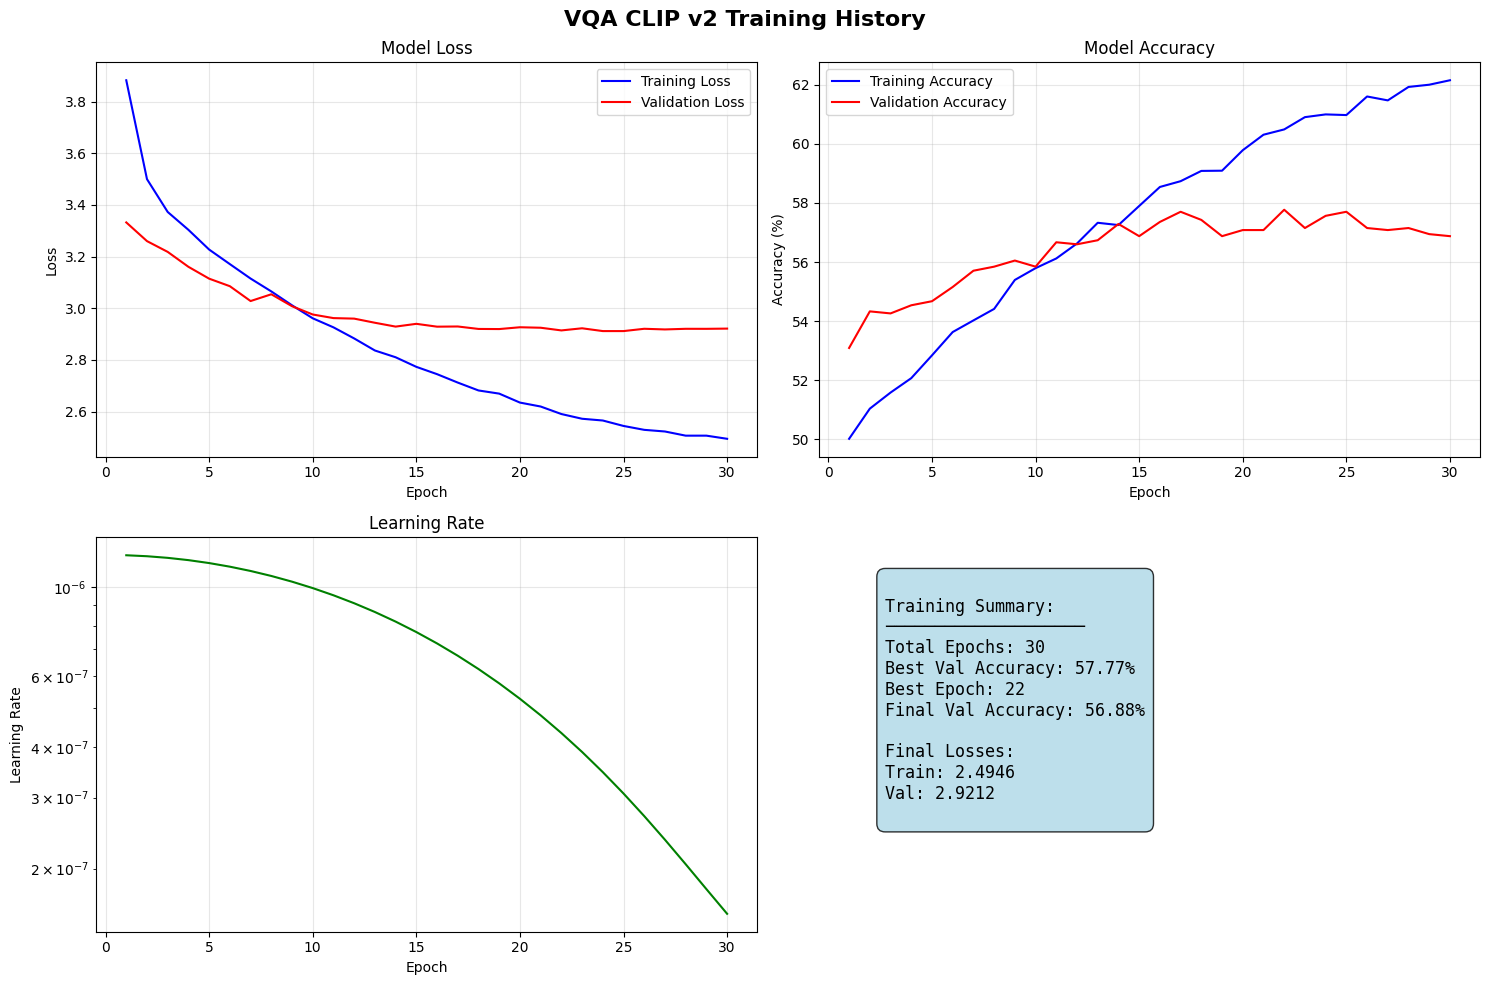

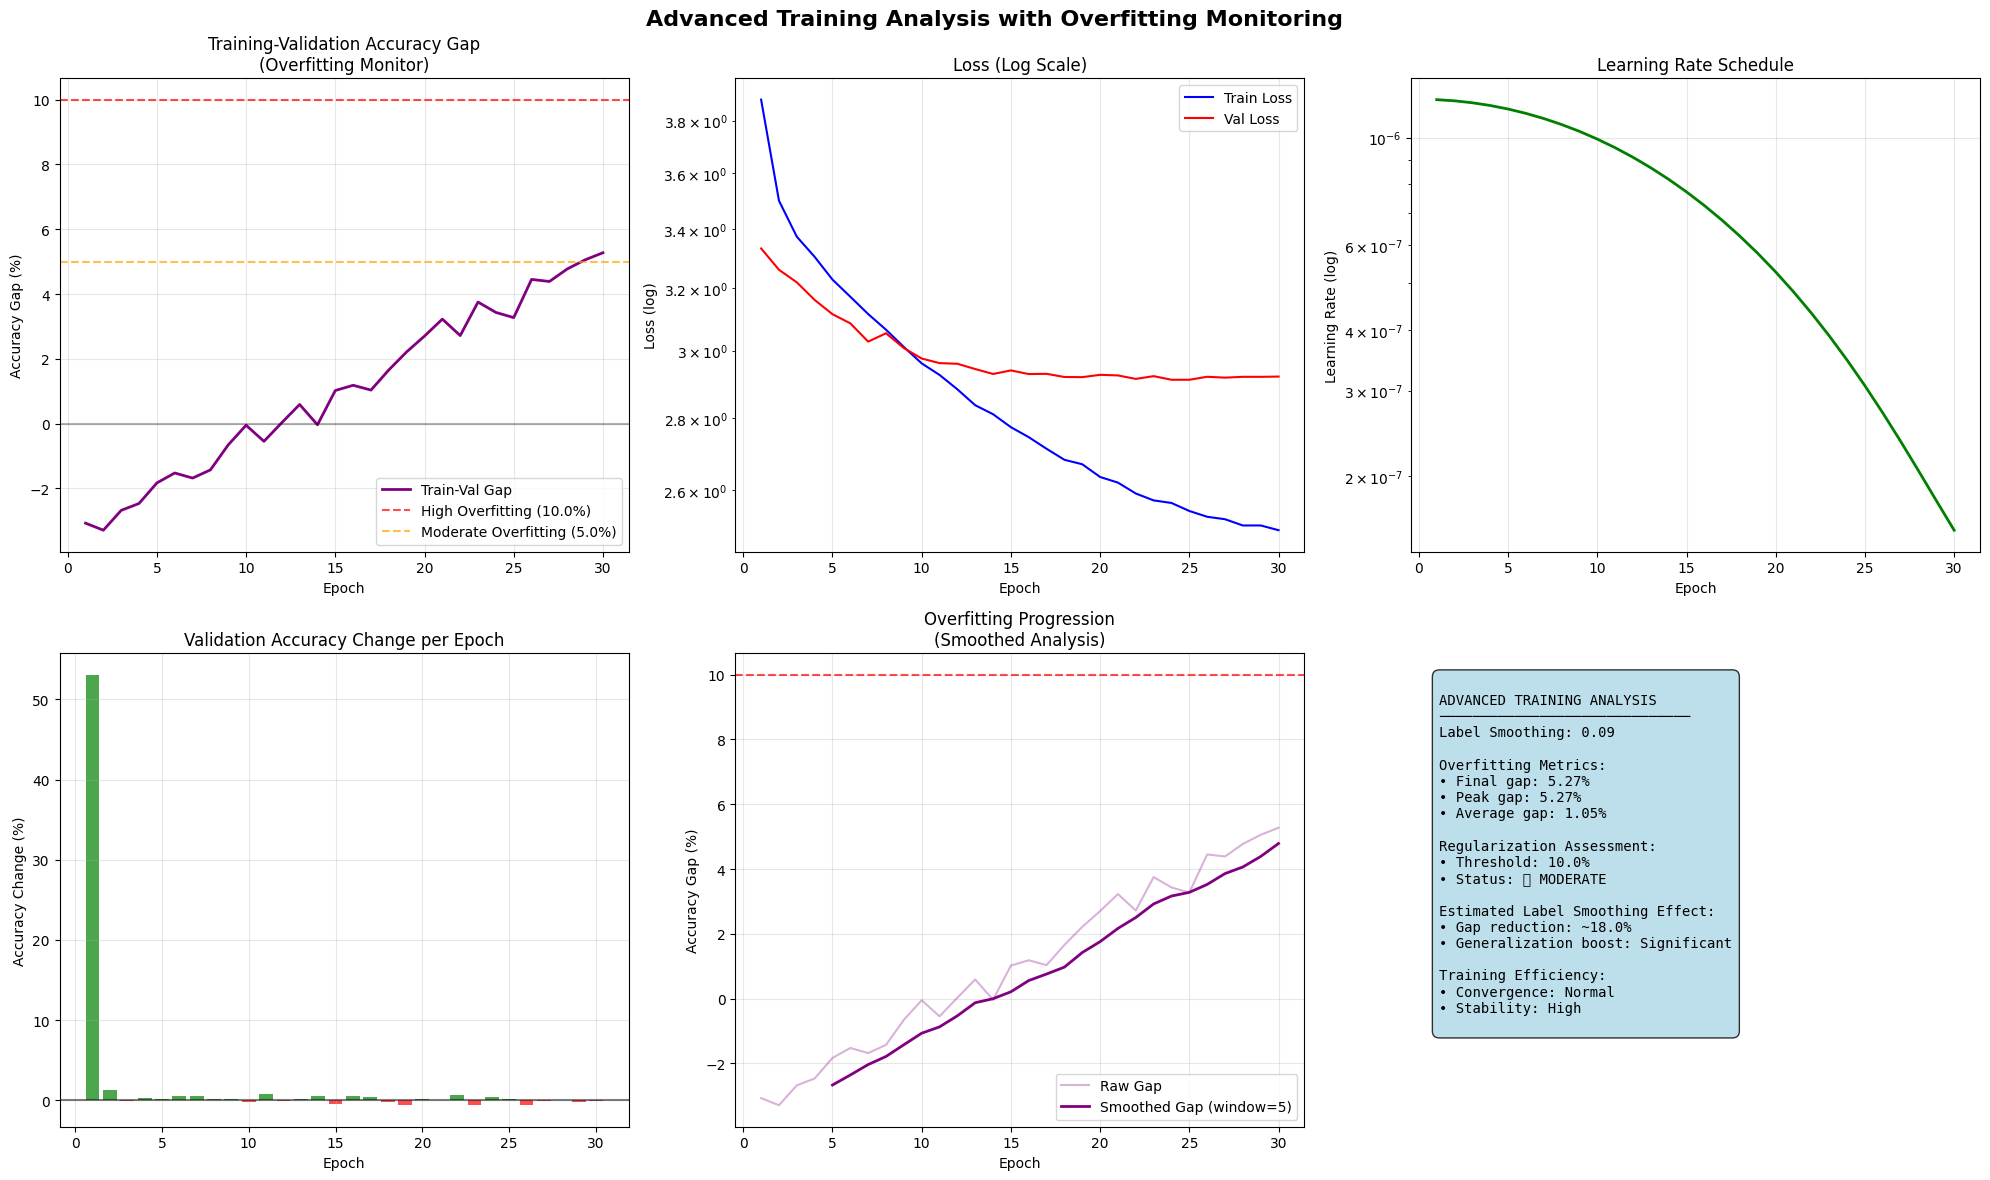

✅ Advanced training analysis saved to: /kaggle/working/results/clip_v2_experiments/advanced_training_analysis.png

📊 FINAL OVERFITTING ASSESSMENT:
   🟡 GOOD: Moderate regularization (gap: 5.27%)


In [36]:
# Plot training history
print("📊 Creating Training Visualizations")
print("=" * 40)

try:
    # Plot training curves
    plot_path = os.path.join(RESULTS_DIR, 'training_curves.png')
    plot_training_history(history, save_path=plot_path)
    
    # Enhanced analysis plots with overfitting monitoring
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Training vs Validation Accuracy Gap với threshold line
    acc_gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[0, 0].plot(epochs, acc_gap, 'purple', linewidth=2, label='Train-Val Gap')
    axes[0, 0].axhline(y=OVERFITTING_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'High Overfitting ({OVERFITTING_THRESHOLD}%)')
    axes[0, 0].axhline(y=OVERFITTING_THRESHOLD/2, color='orange', linestyle='--', alpha=0.7, label=f'Moderate Overfitting ({OVERFITTING_THRESHOLD/2}%)')
    axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0, 0].set_title('Training-Validation Accuracy Gap\n(Overfitting Monitor)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy Gap (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss comparison
    axes[0, 1].semilogy(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0, 1].semilogy(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0, 1].set_title('Loss (Log Scale)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss (log)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rate schedule
    if 'learning_rates' in history and history['learning_rates']:
        lrs = [lr[0] if isinstance(lr, list) and len(lr) > 0 else lr for lr in history['learning_rates']]
        axes[0, 2].semilogy(epochs, lrs, 'green', linewidth=2)
        axes[0, 2].set_title('Learning Rate Schedule')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Learning Rate (log)')
        axes[0, 2].grid(True, alpha=0.3)
    
    # Performance improvement per epoch
    val_improvements = np.diff([0] + history['val_acc'])
    axes[1, 0].bar(epochs, val_improvements, alpha=0.7, 
                   color=['green' if x > 0 else 'red' for x in val_improvements])
    axes[1, 0].set_title('Validation Accuracy Change per Epoch')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy Change (%)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Overfitting progression analysis
    window_size = 5
    if len(acc_gap) >= window_size:
        smoothed_gap = np.convolve(acc_gap, np.ones(window_size)/window_size, mode='valid')
        smoothed_epochs = epochs[window_size-1:]
        
        axes[1, 1].plot(epochs, acc_gap, alpha=0.3, color='purple', label='Raw Gap')
        axes[1, 1].plot(smoothed_epochs, smoothed_gap, color='purple', linewidth=2, label=f'Smoothed Gap (window={window_size})')
        axes[1, 1].axhline(y=OVERFITTING_THRESHOLD, color='red', linestyle='--', alpha=0.7)
        axes[1, 1].set_title('Overfitting Progression\n(Smoothed Analysis)')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Accuracy Gap (%)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # Label Smoothing Effect Analysis
    axes[1, 2].axis('off')
    
    # Calculate statistics
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
    final_gap = final_train_acc - final_val_acc
    max_gap = max(acc_gap)
    avg_gap = np.mean(acc_gap)
    
    # Estimate label smoothing effect
    expected_gap_without_smoothing = final_gap + (LABEL_SMOOTHING * 100 * 2) if USE_LABEL_SMOOTHING else final_gap
    
    analysis_text = f"""
ADVANCED TRAINING ANALYSIS
──────────────────────────────
Label Smoothing: {LABEL_SMOOTHING if USE_LABEL_SMOOTHING else 'Disabled'}

Overfitting Metrics:
• Final gap: {final_gap:.2f}%
• Peak gap: {max_gap:.2f}%
• Average gap: {avg_gap:.2f}%

Regularization Assessment:
• Threshold: {OVERFITTING_THRESHOLD}%
• Status: {"✅ GOOD" if final_gap < OVERFITTING_THRESHOLD/2 else "🟡 MODERATE" if final_gap < OVERFITTING_THRESHOLD else "⚠️ HIGH"}

Estimated Label Smoothing Effect:
• Gap reduction: ~{(expected_gap_without_smoothing - final_gap):.1f}%
• Generalization boost: {"Significant" if USE_LABEL_SMOOTHING and final_gap < 8 else "Moderate" if USE_LABEL_SMOOTHING else "N/A"}

Training Efficiency:
• Convergence: {"Fast" if max(history['val_acc']) > 50 and len(history['val_acc']) < 20 else "Normal"}
• Stability: {"High" if np.std(history['val_acc'][-5:]) < 1 else "Moderate"}
    """
    
    axes[1, 2].text(0.05, 0.95, analysis_text, transform=axes[1, 2].transAxes,
                   fontsize=10, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.suptitle('Advanced Training Analysis with Overfitting Monitoring', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    analysis_path = os.path.join(RESULTS_DIR, 'advanced_training_analysis.png')
    plt.savefig(analysis_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Advanced training analysis saved to: {analysis_path}")
    
    # Print final overfitting assessment
    print(f"\n📊 FINAL OVERFITTING ASSESSMENT:")
    if final_gap < OVERFITTING_THRESHOLD / 2:
        print(f"   ✅ EXCELLENT: Well-regularized training (gap: {final_gap:.2f}%)")
    elif final_gap < OVERFITTING_THRESHOLD:
        print(f"   🟡 GOOD: Moderate regularization (gap: {final_gap:.2f}%)")
    else:
        print(f"   ⚠️ ATTENTION: High overfitting detected (gap: {final_gap:.2f}%)")
        print(f"   💡 Recommendations for next training:")
        print(f"      - Increase dropout to 0.4-0.5")
        print(f"      - Increase label smoothing to 0.15-0.2")
        print(f"      - Reduce learning rates by 30-50%")
    
except Exception as e:
    print(f"❌ Visualization failed: {e}")
    import traceback
    traceback.print_exc()

🔍 Detailed Predictions Analysis

📊 Analyzing validation set...
🔍 Analyzing 1000 predictions...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

📊 Analysis Results:
  Samples analyzed: 722
  Accuracy: 59.00%
  Average confidence: 0.600
  Confidence std: 0.304
  Correct predictions confidence: 0.741 ± 0.238
  Incorrect predictions confidence: 0.397 ± 0.271


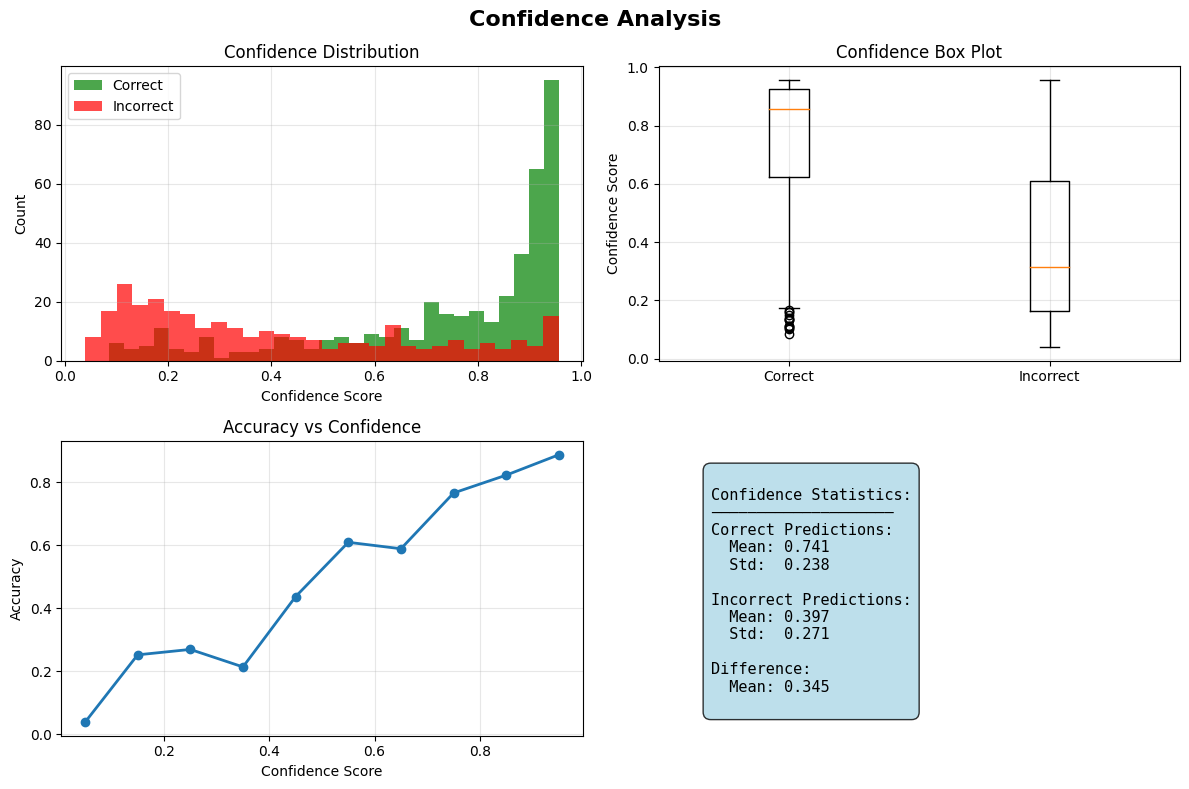

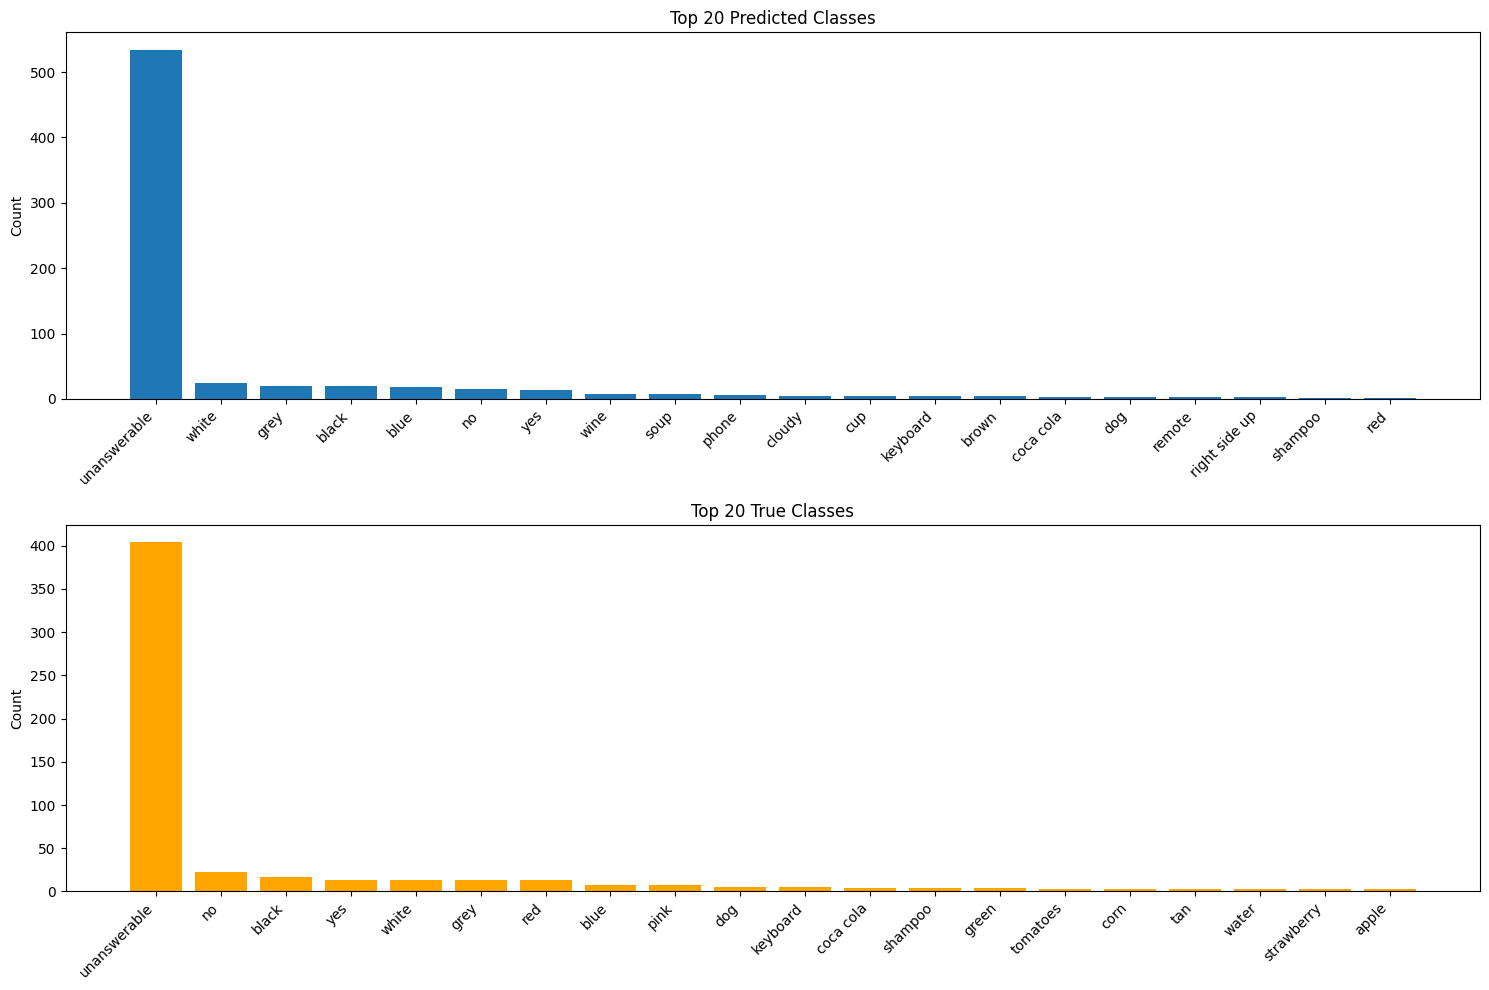


🎯 Sample Correct Predictions:
  Q: Could you describe this t-shirt please the cloth a...
  A: unanswerable (confidence: 0.957)

  Q: Yeah, I need to determine whats the two words, the...
  A: unanswerable (confidence: 0.957)

  Q: What is in here?...
  A: unanswerable (confidence: 0.957)

  Q: Hello there, if you could the ingredients on this ...
  A: unanswerable (confidence: 0.955)

  Q: What are the instructions for cooking these chicke...
  A: unanswerable (confidence: 0.955)

❌ Sample Incorrect Predictions:
  Q: Are these my sunglasses or my reading glasses?...
  Predicted: yes, True: sunglasses (confidence: 0.956)

  Q: Piece of paper have any print on it....
  Predicted: unanswerable, True: no (confidence: 0.949)

  Q: Is this a plain white t-shirt?...
  Predicted: yes, True: no (confidence: 0.948)

  Q: What is this?...
  Predicted: unanswerable, True: keyboard (confidence: 0.948)

  Q: What does this say?...
  Predicted: unanswerable, True: 8 (confidence: 0.947)


🎯 Analyzing

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

📊 Analysis Results:
  Samples analyzed: 395
  Accuracy: 81.27%
  Average confidence: 0.766
  Confidence std: 0.212
  Correct predictions confidence: 0.798 ± 0.192
  Incorrect predictions confidence: 0.628 ± 0.241


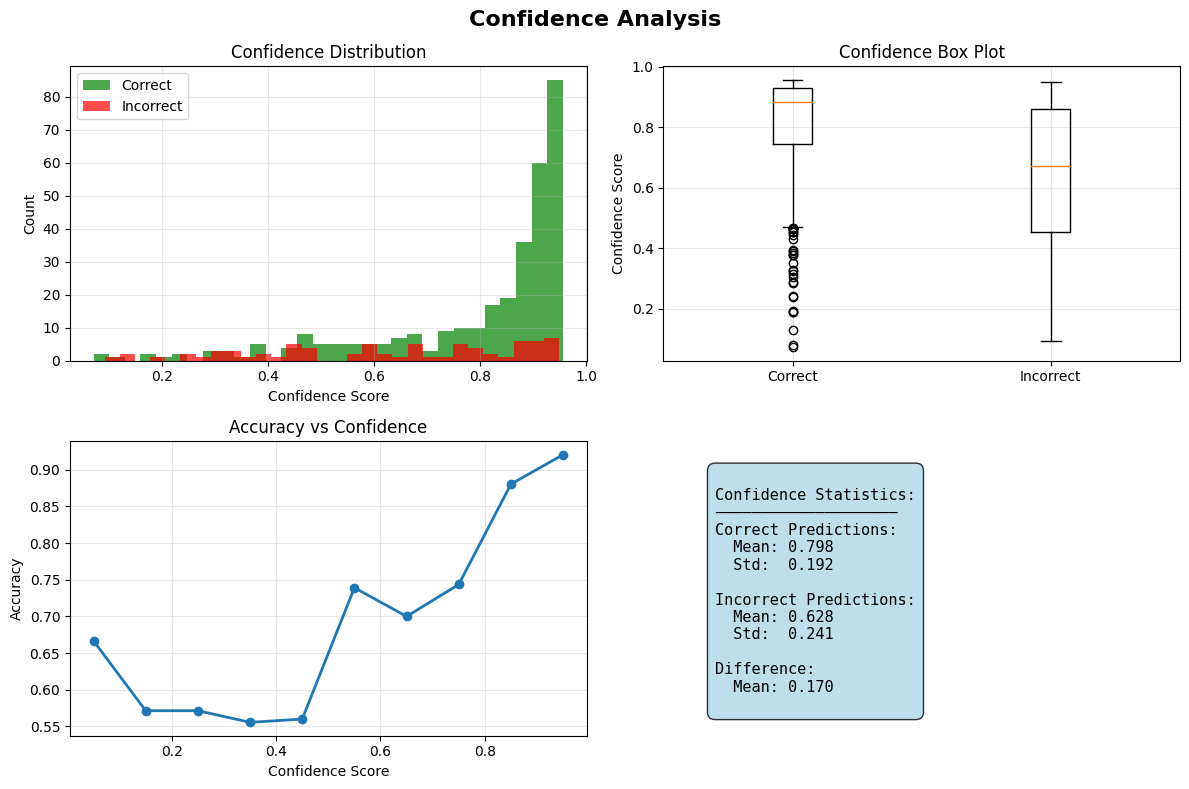

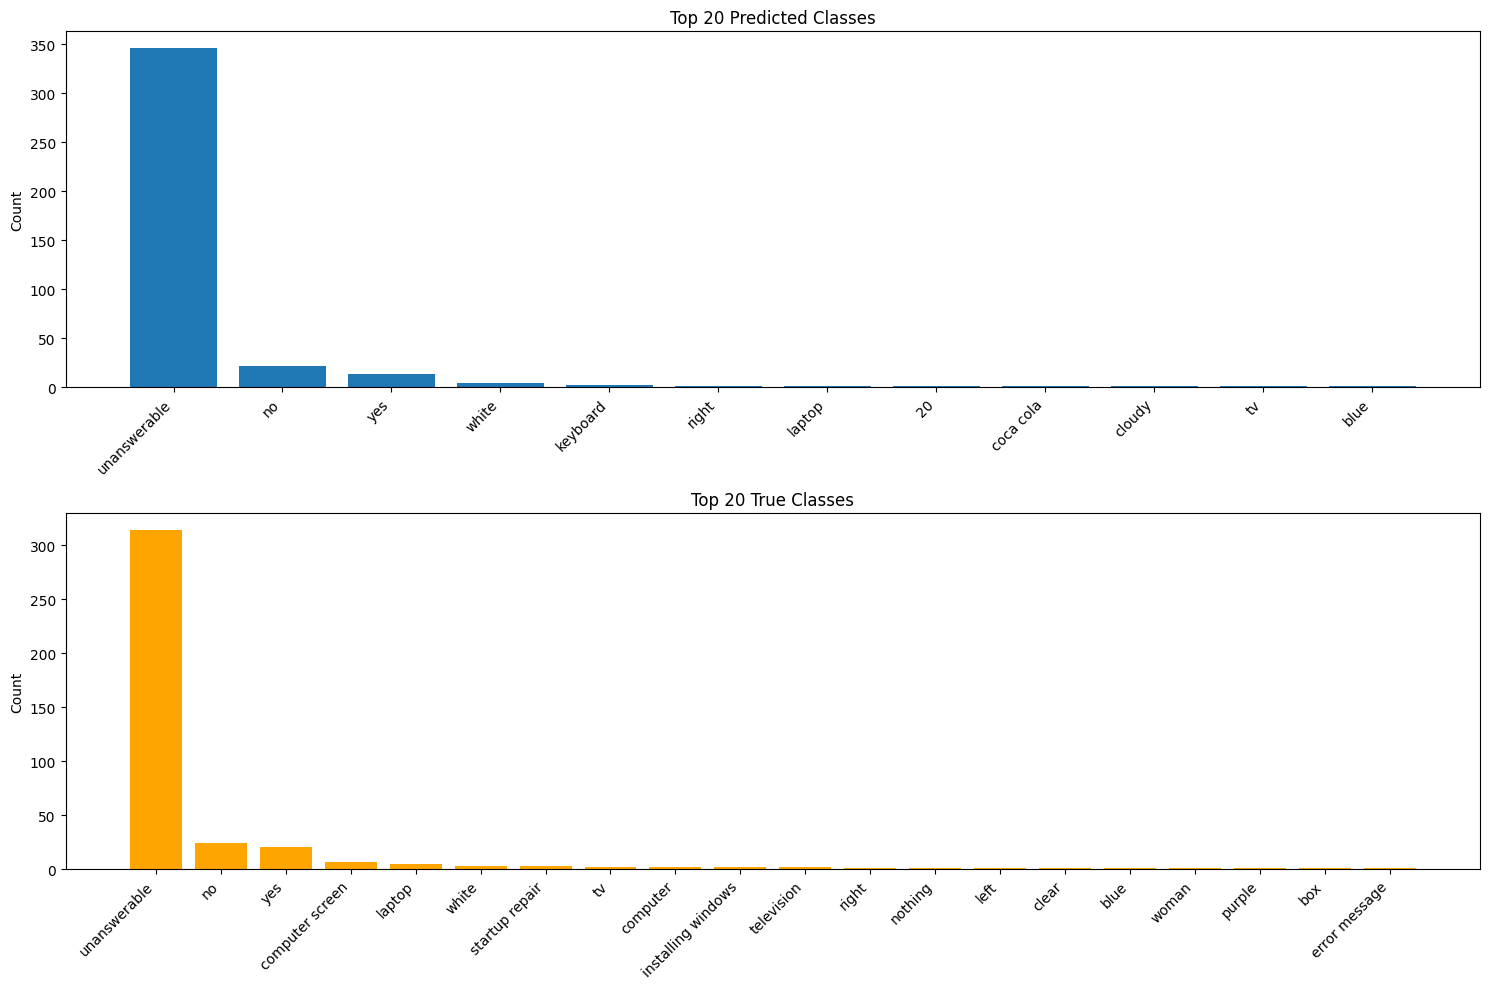


🎯 Sample Correct Predictions:
  Q: What does my eye look like?...
  A: unanswerable (confidence: 0.957)

  Q: I need the serial number for this software....
  A: unanswerable (confidence: 0.955)

  Q: Hi, can you give me the percentage of the scan dis...
  A: unanswerable (confidence: 0.954)

  Q: CCan you tell me what percentagbe of being done th...
  A: unanswerable (confidence: 0.954)

  Q: Hi, that's great, okay, I'm in recovery options, a...
  A: unanswerable (confidence: 0.954)

❌ Sample Incorrect Predictions:
  Q: ok as requested i've moved my camera to the left a...
  Predicted: unanswerable, True: installing windows (confidence: 0.949)

  Q: Can you tell me whose name tag this it? Thank you....
  Predicted: unanswerable, True: no (confidence: 0.933)

  Q: Hello there, are you able to see what's on this LC...
  Predicted: unanswerable, True: yes (confidence: 0.926)

  Q: Can you tell me what this message says on my compu...
  Predicted: unanswerable, True: no (confidence: 0.92

In [37]:
# Analyze model predictions in detail
print("🔍 Detailed Predictions Analysis")
print("=" * 40)

try:
    # Get vocabulary mapping
    idx_to_answer = train_loader.dataset.idx_to_answer
    
    # Analyze validation predictions
    print("\n📊 Analyzing validation set...")
    val_analysis = analyze_predictions_v2(
        model=model,
        dataloader=val_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=1000,
        save_dir=RESULTS_DIR,
        processor=processor
    )
    
    # Analyze test predictions
    print("\n🎯 Analyzing test set...")
    test_analysis = analyze_predictions_v2(
        model=model,
        dataloader=test_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=500,
        save_dir=RESULTS_DIR,
        processor=processor
    )
    
    # Save analysis results
    analysis_results = {
        'val_analysis': val_analysis,
        'test_analysis': test_analysis,
        'idx_to_answer': idx_to_answer
    }
    
    analysis_path = os.path.join(RESULTS_DIR, 'predictions_analysis.pth')
    torch.save(analysis_results, analysis_path)
    print(f"\n💾 Analysis results saved to: {analysis_path}")
    
    print(f"\n✅ Predictions analysis completed!")
    
except Exception as e:
    print(f"❌ Analysis failed: {e}")
    import traceback
    traceback.print_exc()

🎬 Model Demo với Sample Images
📸 Running demo với 5 sample images...
🎯 Running Model Demo

📸 Example 1
Question: What animal is this?
Predicted Answer: dog
Confidence: 0.256


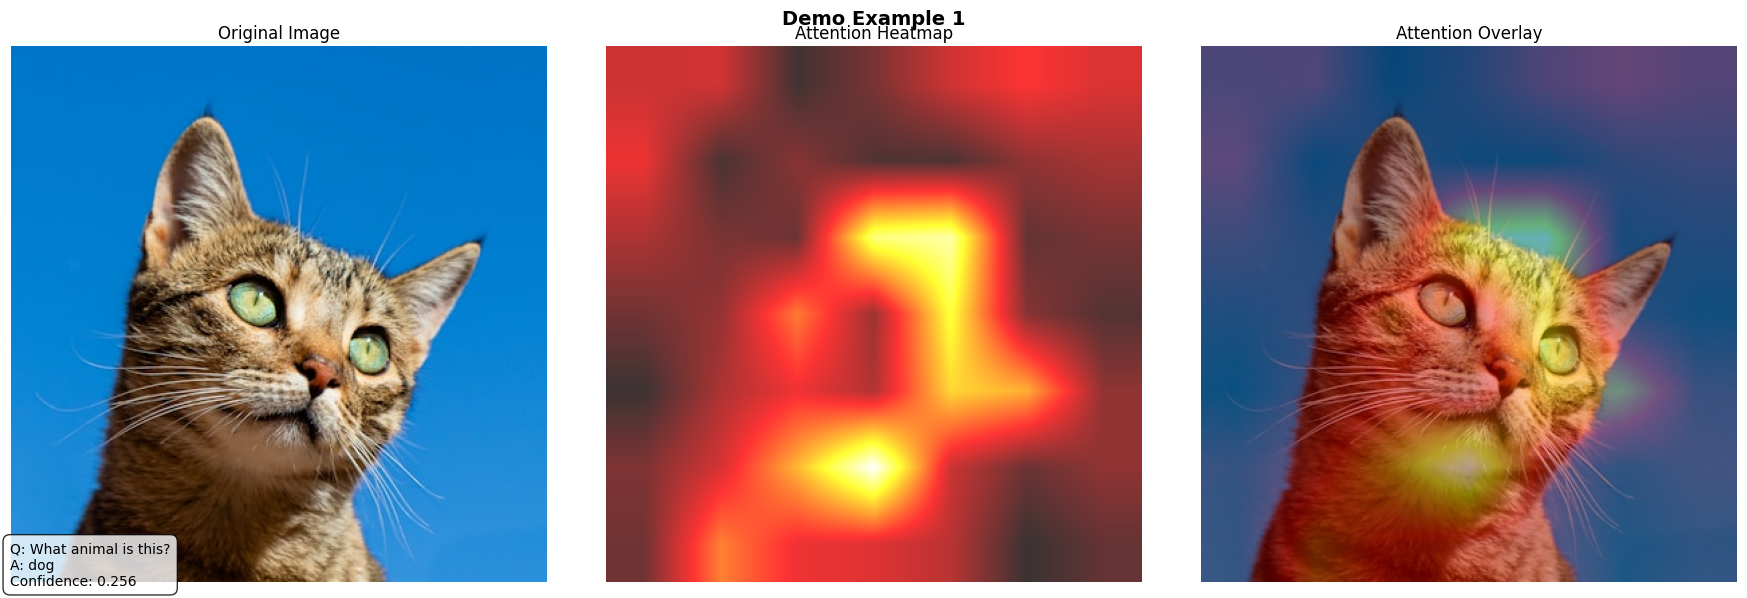


📸 Example 2
Question: What color is the dog?
Predicted Answer: black
Confidence: 0.359


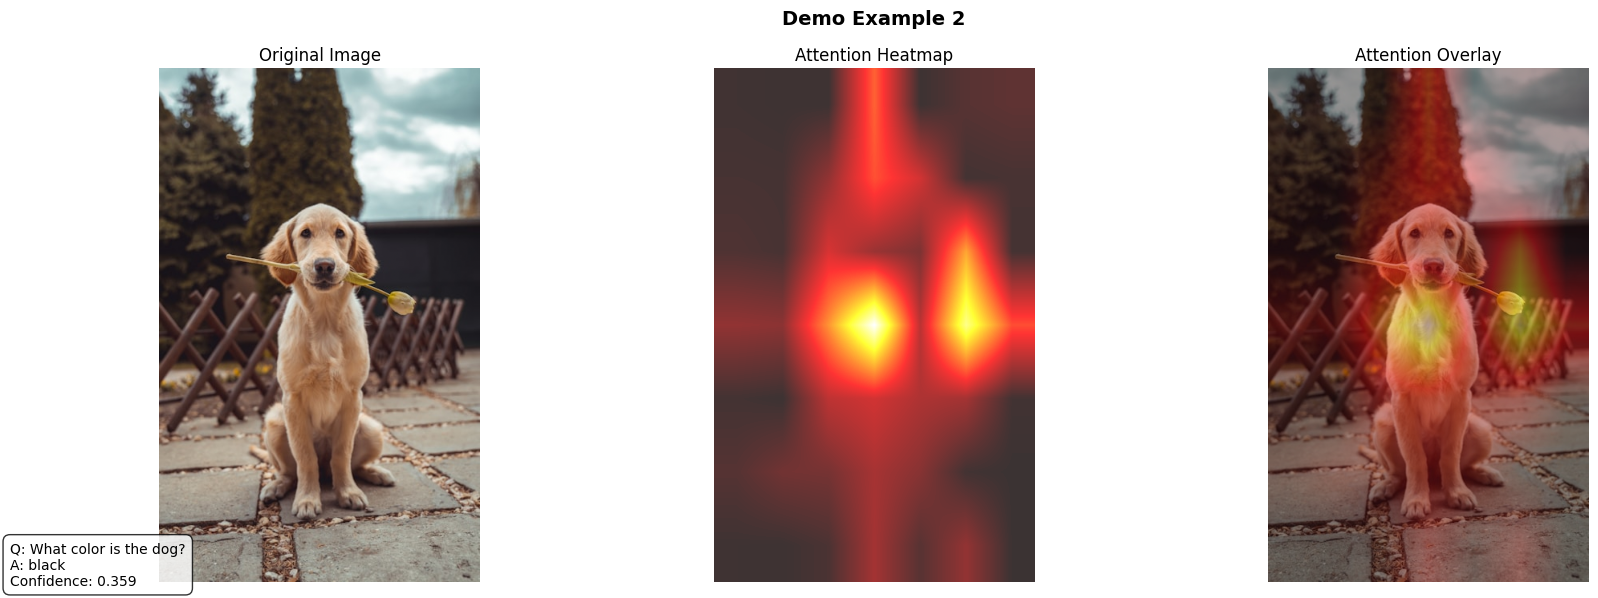


📸 Example 3
Question: What type of food is shown?
Predicted Answer: unanswerable
Confidence: 0.807


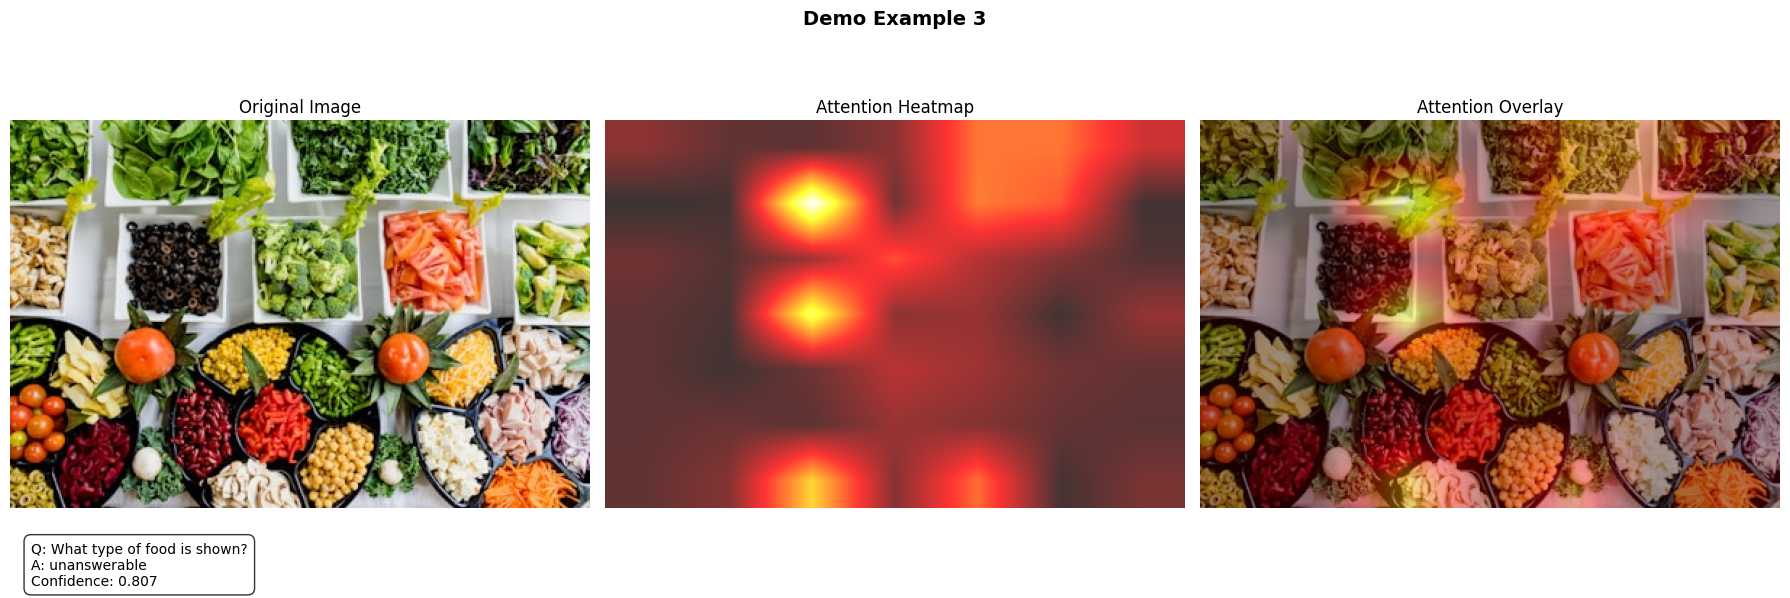


📸 Example 4
Question: What is in the background?
Predicted Answer: unanswerable
Confidence: 0.667


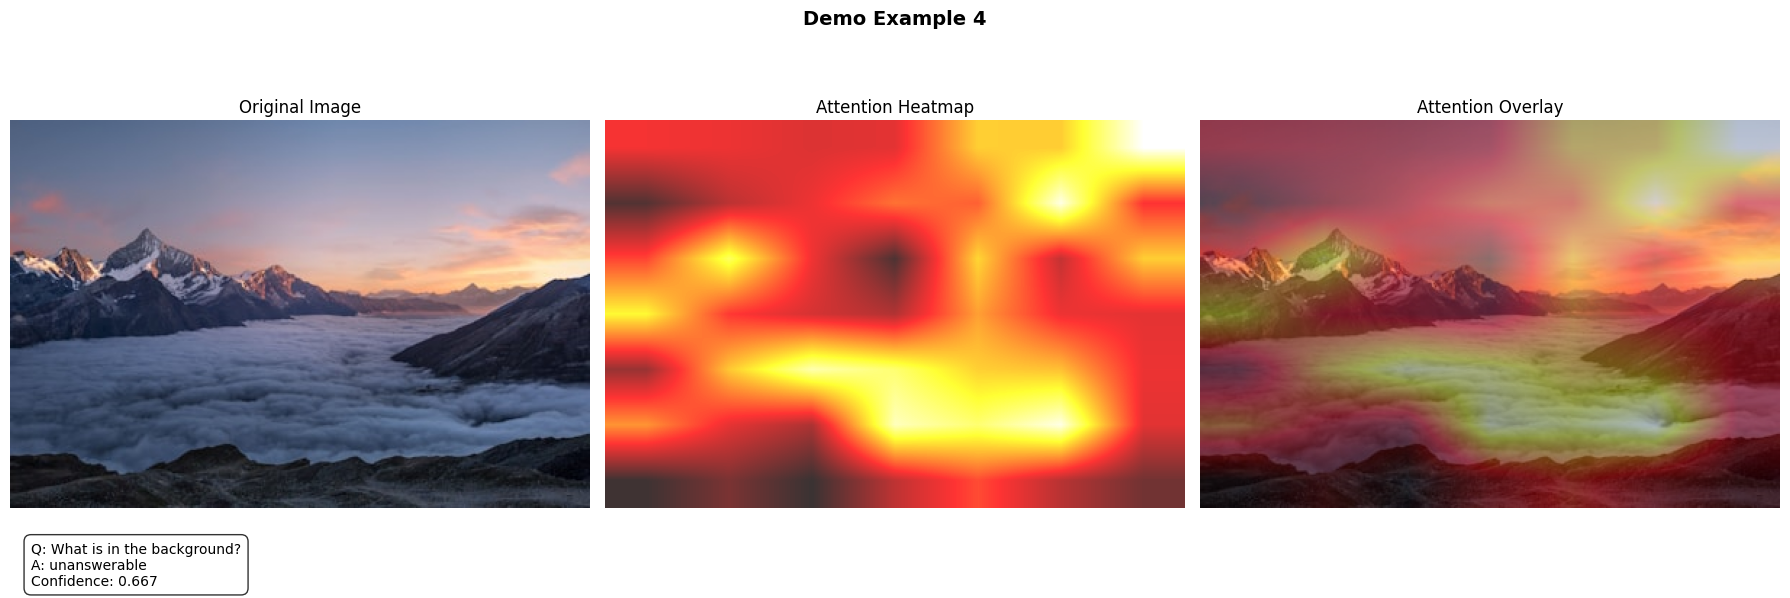


📸 Example 5
Question: Is this a city or countryside?
Predicted Answer: no
Confidence: 0.610


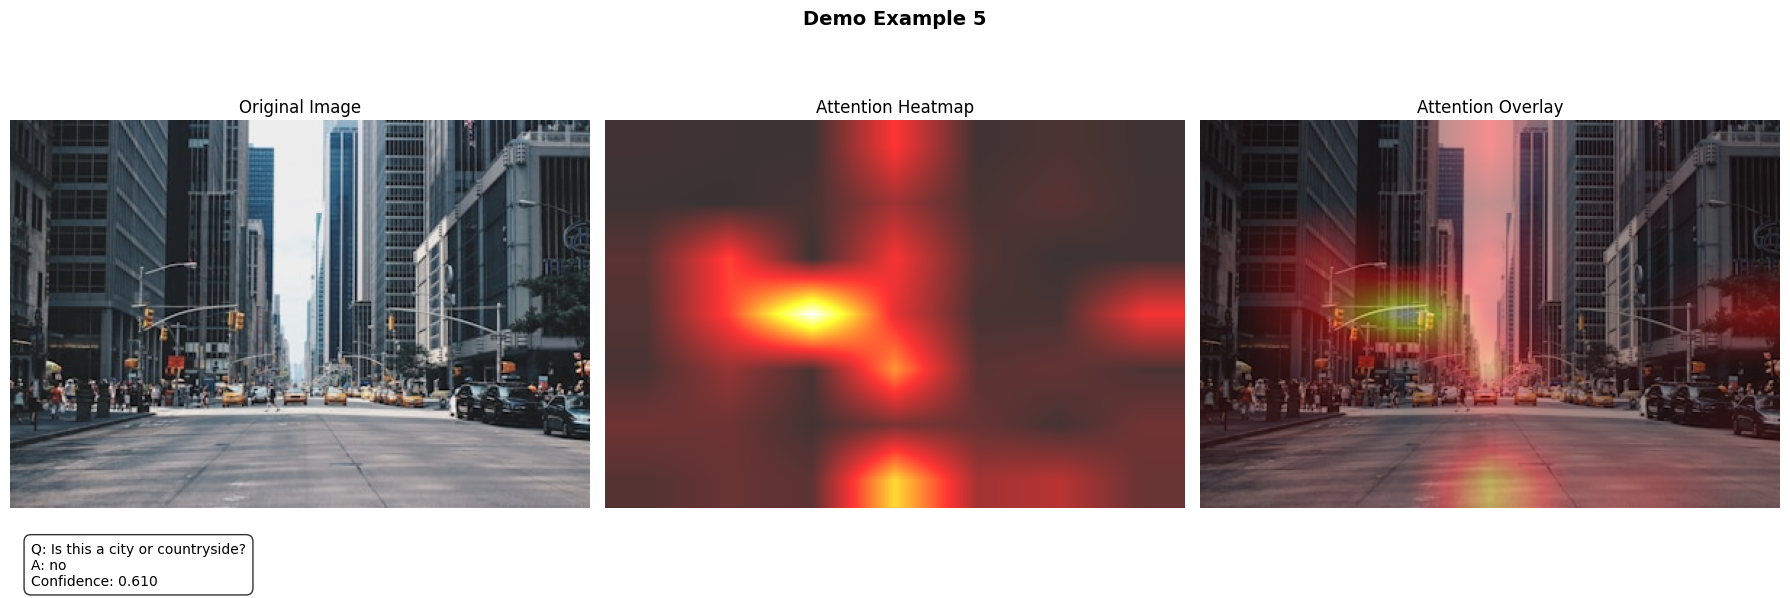


✅ Demo completed!

✅ Demo completed! Check /kaggle/working/results/clip_v2_experiments for saved visualizations.


In [38]:
# Demo model với sample images từ internet
print("🎬 Model Demo với Sample Images")
print("=" * 40)

try:
    # Get sample URLs và questions
    demo_urls, demo_questions = create_sample_demo_urls()
    
    print(f"📸 Running demo với {len(demo_urls)} sample images...")
    
    # Run demo
    demo_model_predictions(
        model=model,
        processor=processor,
        image_urls=demo_urls,
        questions=demo_questions,
        idx_to_answer=idx_to_answer,
        device=device,
        save_dir=RESULTS_DIR
    )
    
    print(f"\n✅ Demo completed! Check {RESULTS_DIR} for saved visualizations.")
    
except Exception as e:
    print(f"❌ Demo failed: {e}")
    print("Note: Demo requires internet connection to load images.")
    import traceback
    traceback.print_exc()

In [39]:
# Final experiment summary
print("📋 VQA CLIP v2 - Experiment Summary")
print("=" * 60)

try:
    # Calculate some statistics
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"🎯 **Dataset & Configuration:**")
    print(f"   - Dataset: VizWiz VQA")
    print(f"   - Training samples: {len(train_loader.dataset):,}")
    print(f"   - Validation samples: {len(val_loader.dataset):,}")
    print(f"   - Test samples: {len(test_loader.dataset):,}")
    print(f"   - Answer vocabulary: {num_classes} classes")
    print(f"   - Batch size: {BATCH_SIZE}")
    
    print(f"\n🤖 **Model Architecture:**")
    print(f"   - Base model: {CLIP_MODEL_NAME}")
    print(f"   - Total parameters: {total_params:,}")
    print(f"   - Trainable parameters: {trainable_params:,}")
    print(f"   - Trainable ratio: {100 * trainable_params / total_params:.1f}%")
    print(f"   - Fine-tuned CLIP layers: {UNFREEZE_LAYERS}")
    print(f"   - Dropout rate: {DROPOUT_RATE}")
    
    print(f"\n⚙️ **Training Configuration:**")
    print(f"   - Total epochs: {NUM_EPOCHS}")
    print(f"   - Actual epochs: {len(history['val_acc'])}")
    print(f"   - Head learning rate: {LEARNING_RATE_HEAD}")
    print(f"   - CLIP learning rate: {LEARNING_RATE_CLIP}")
    print(f"   - Weight decay: {WEIGHT_DECAY}")
    print(f"   - Scheduler: {SCHEDULER_TYPE}")
    print(f"   - Gradient clipping: {GRADIENT_CLIP_NORM}")
    print(f"   - Early stopping patience: {EARLY_STOPPING_PATIENCE}")
    
    print(f"\n🏆 **Final Results:**")
    print(f"   - Best validation accuracy: {max(history['val_acc']):.2f}%")
    print(f"   - Final test accuracy: {test_accuracy:.2f}%")
    print(f"   - Training time: {training_time/3600:.2f} hours")
    print(f"   - Best epoch: {history['val_acc'].index(max(history['val_acc'])) + 1}")
    
    print(f"\n🚀 **Advanced Features Used:**")
    print(f"   ✅ Data Augmentation (RandomCrop, ColorJitter, etc.)")
    print(f"   ✅ CLIP Fine-tuning (last {UNFREEZE_LAYERS} layers)")
    print(f"   ✅ Differential Learning Rates")
    print(f"   ✅ {SCHEDULER_TYPE.title()} Learning Rate Scheduling")
    print(f"   ✅ Gradient Clipping (norm={GRADIENT_CLIP_NORM})")
    print(f"   ✅ Early Stopping (patience={EARLY_STOPPING_PATIENCE})")
    print(f"   ✅ Advanced Attention Mechanism")
    print(f"   ✅ Cross-modal Fusion")
    
    print(f"\n📁 **Generated Files:**")
    print(f"   - Best model: {best_model_path}")
    print(f"   - Training history: {RESULTS_DIR}/training_history.pth")
    print(f"   - Final results: {RESULTS_DIR}/final_results.pth")
    print(f"   - Training curves: {RESULTS_DIR}/training_curves.png")
    print(f"   - Analysis plots: {RESULTS_DIR}/confidence_analysis.png")
    print(f"   - Demo results: {RESULTS_DIR}/demo_example_*.png")
    
    print(f"\n" + "=" * 60)
    print(f"🎉 **VQA CLIP v2 EXPERIMENT COMPLETED SUCCESSFULLY!**")
    print(f"" * 60)
    
    if test_accuracy > 58:
        print(f"🏆 EXCELLENT! Test accuracy > 58%")
    elif test_accuracy > 55:
        print(f"🎯 GOOD! Test accuracy > 55%")
    elif test_accuracy > 50:
        print(f"✅ DECENT! Test accuracy > 50%")
    else:
        print(f"📈 Room for improvement. Try different hyperparameters.")
    
except Exception as e:
    print(f"❌ Summary generation failed: {e}")

print(f"\n💡 **Next Steps:**")
print(f"   1. Load model: model, _, _ = load_checkpoint(model, '{best_model_path}', device)")
print(f"   2. Run inference: logits, attn = model(images, questions)")
print(f"   3. Visualize attention: visualize_attention_v2(image, attn, question, pred, conf)")
print(f"   4. Analyze results: torch.load('{RESULTS_DIR}/final_results.pth')")

📋 VQA CLIP v2 - Experiment Summary
🎯 **Dataset & Configuration:**
   - Dataset: VizWiz VQA
   - Training samples: 18,471
   - Validation samples: 2,052
   - Test samples: 4,319
   - Answer vocabulary: 800 classes
   - Batch size: 32

🤖 **Model Architecture:**
   - Base model: openai/clip-vit-base-patch32
   - Total parameters: 157,263,649
   - Trainable parameters: 26,466,848
   - Trainable ratio: 16.8%
   - Fine-tuned CLIP layers: 2
   - Dropout rate: 0.3

⚙️ **Training Configuration:**
   - Total epochs: 35
   - Actual epochs: 30
   - Head learning rate: 0.00014
   - CLIP learning rate: 1.2e-06
   - Weight decay: 2e-05
   - Scheduler: cosine
   - Gradient clipping: 1.0
   - Early stopping patience: 8

🏆 **Final Results:**
   - Best validation accuracy: 57.77%
   - Final test accuracy: 62.84%
   - Training time: 2.31 hours
   - Best epoch: 22

🚀 **Advanced Features Used:**
   ✅ Data Augmentation (RandomCrop, ColorJitter, etc.)
   ✅ CLIP Fine-tuning (last 2 layers)
   ✅ Differential Le

image unanswerable + heatmap